# DATA102 Project: Modeling Degree ROI Through University Financial Data
**Companion Codebase & Empirical Replication Notebook**

**Group 1**
- Antiado, Leonna F.
- Cuevas, Gheann Christie M.
- Divina, Precious Mae M.
- Martinez, Mikaella Kaye A.
- Sison, Aaron Joshua E.

*Course:* DATA102 – Data Mining  
*Institution:* Department of Software Technology, College of Computer Studies, De La Salle University  
*Date:* August 10, 2026

## Phase 1: Data Preparation, Cleaning, & Exploratory Data Analysis

### 1. Dataset Overview & Variables

The analytical dataset is derived from the United States Department of Education **College Scorecard** administrative database, comprising $N = 6,273$ raw postsecondary institutions evaluated across 24 attributes. It tracks institutional tuition pricing, student debt burdens, and post-graduation labor-market outcomes ten years after initial enrollment.

Our core target variable is 10-year median earnings (`MD_EARN_WNE_P10`), measured in USD for working Title IV aid recipients. Published in-state tuition and fees (`TUITIONFEE_IN`) serves as our primary predictor, while institutional ownership classification (`CONTROL`: Public, Private Nonprofit, For-Profit) acts as the primary moderator. Cumulative graduate debt (`GRAD_DEBT_MDN`) captures debt mediation, while total undergraduate enrollment (`UGDS`), predominant degree awarded (`PREDDEG`), state location (`STABBR`), and admissions selectivity (`ADM_RATE`, `SAT_AVG`) provide essential structural and geographic controls.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from IPython.display import display

# QVRS style configuration
import matplotlib.font_manager as font_manager

def set_quant_style():
    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    font_family = "Georgia" if "Georgia" in available_fonts else "DejaVu Sans"
    sns.set_theme(style="white")
    plt.rcParams.update({
        "font.family": font_family,
        "axes.grid": True,
        "grid.color": "#F2F2F2",
        "grid.linewidth": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": False,
        "axes.spines.bottom": True,
        "axes.titleweight": "bold",
        "axes.titlesize": 14,
        "axes.labelweight": "bold",
        "axes.labelsize": 10,
        "legend.frameon": False,
        "xtick.major.size": 0,
        "ytick.major.size": 0,
        "text.color": "#0D0D0D",
        "axes.labelcolor": "#333333",
        "xtick.color": "#333333",
        "ytick.color": "#333333"
    })

set_quant_style()


### 2. Data Cleaning Pipeline

To prepare our dataset for valid empirical analysis, the following code guides the raw College Scorecard database through a multi-step cleaning pipeline. First, it loads the raw file containing $6,273$ institutions and targets the graduate debt column, coercing non-numeric string suppressions like `PrivacySuppressed` directly into missing numeric values using `pd.to_numeric(errors=coerce)`, following **Pepinsky (2018)** on handling suppressed administrative survey fields. Next, it isolates our core economic metrics by dropping rows that lack either 10-year median earnings or published in-state tuition, while also removing single zero-tuition anomalies to maintain a strictly positive cost baseline required for natural log transformations ($\log(	ext{Tuition})$), following **Muse & Muse (2024)**. To avoid throwing away valid institutional data, missing undergraduate enrollment values are filled using sector-specific medians rather than a global average, preserving the fundamental scale differences between large public universities and small private colleges, following **Faber (2017)**. Finally, the script trims extreme distribution tails by applying symmetric Interquartile Range bounds to median earnings between $\$11,818$ and $\$84,278$, alongside sector-stratified tuition bounds, following **Faber & Slantcheva-Durst (2021)** and **Muse & Muse (2024)**, before encoding numerical ownership classifications into human-readable sector labels. This leaves us with a clean analytical baseline of $N = 2,894$ postsecondary institutions.

In [2]:
# DATA CLEANING PIPELINE
# Step 1: Load the dataset
df_raw = pd.read_csv('data/final_datasets/College_Scorecard_Subset.csv', low_memory=False)
initial_count = len(df_raw)

# Step 2: Print raw shape and null counts for variables of interest
target_vars = ['TUITIONFEE_IN', 'MD_EARN_WNE_P10', 'GRAD_DEBT_MDN', 'CONTROL', 'UGDS']
print(f"Raw dataset shape: {df_raw.shape}")
print("\nNull counts in variables of interest:")
print(df_raw[target_vars].isnull().sum())

# Step 3: GRAD_DEBT_MDN — convert 'PS' (PrivacySuppressed) strings to NaN
n_before = df_raw['GRAD_DEBT_MDN'].notna().sum()
df_raw['GRAD_DEBT_MDN'] = pd.to_numeric(df_raw['GRAD_DEBT_MDN'], errors='coerce')
n_after = df_raw['GRAD_DEBT_MDN'].notna().sum()
suppressed_dropped = n_before - n_after
print(f"\nGRAD_DEBT_MDN: {suppressed_dropped} PrivacySuppressed values coerced to NaN (dtype now: {df_raw['GRAD_DEBT_MDN'].dtype})")
print(f"GRAD_DEBT_MDN null after coercion: {df_raw['GRAD_DEBT_MDN'].isnull().sum()}")

# Step 4: Drop rows where MD_EARN_WNE_P10 or TUITIONFEE_IN is null
count_before = len(df_raw)
df_raw = df_raw.dropna(subset=['MD_EARN_WNE_P10', 'TUITIONFEE_IN'])
null_target_rows = count_before - len(df_raw)
print(f"\nDropped {null_target_rows} rows missing MD_EARN_WNE_P10 or TUITIONFEE_IN. Remaining: {len(df_raw)}")

# Step 5: Drop rows where TUITIONFEE_IN == 0
count_before = len(df_raw)
zero_tuition_rows = (df_raw['TUITIONFEE_IN'] == 0).sum()
df_raw = df_raw[df_raw['TUITIONFEE_IN'] > 0]
print(f"Dropped {zero_tuition_rows} rows with $0 in-state tuition. Remaining: {len(df_raw)}")

# Step 6: Drop rows where GRAD_DEBT_MDN is null after coercion
count_before = len(df_raw)
df_raw = df_raw.dropna(subset=['GRAD_DEBT_MDN'])
debt_null_rows = count_before - len(df_raw)
print(f"Dropped {debt_null_rows} rows with null GRAD_DEBT_MDN. Remaining: {len(df_raw)}")

# Step 7: Impute UGDS nulls with per-CONTROL-group median
ugds_null_before = df_raw['UGDS'].isnull().sum()
df_raw['UGDS'] = df_raw.groupby('CONTROL')['UGDS'].transform(lambda x: x.fillna(x.median()))
ugds_null_after = df_raw['UGDS'].isnull().sum()
print(f"\nUGDS nulls imputed with per-CONTROL-group median: {ugds_null_before} -> {ugds_null_after}")

# Step 8: Check for and drop duplicate UNITID values
dup_unitid_count = df_raw['UNITID'].duplicated().sum()
if dup_unitid_count > 0:
    df_raw = df_raw.drop_duplicates(subset='UNITID', keep='first')
print(f"Duplicate UNITID rows found and dropped: {dup_unitid_count}. Remaining: {len(df_raw)}")

# Step 9: Create CONTROL_LABEL column for readability
control_map = {1: 'Public', 2: 'Private Nonprofit', 3: 'For-Profit'}
df_raw['CONTROL_LABEL'] = df_raw['CONTROL'].map(control_map)
print(f"\nCONTROL_LABEL created. Value counts:")
print(df_raw['CONTROL_LABEL'].value_counts())

# Step 10: Symmetric IQR outlier removal on MD_EARN_WNE_P10 (both tails)
count_before = len(df_raw)
Q1_earn = df_raw['MD_EARN_WNE_P10'].quantile(0.25)
Q3_earn = df_raw['MD_EARN_WNE_P10'].quantile(0.75)
IQR_earn = Q3_earn - Q1_earn
lower_earn = Q1_earn - 1.5 * IQR_earn
upper_earn = Q3_earn + 1.5 * IQR_earn
df_raw = df_raw[(df_raw['MD_EARN_WNE_P10'] >= lower_earn) & (df_raw['MD_EARN_WNE_P10'] <= upper_earn)]
earn_outlier_rows = count_before - len(df_raw)
print(f"\nSymmetric IQR on MD_EARN_WNE_P10: [{lower_earn:.0f}, {upper_earn:.0f}]. Dropped {earn_outlier_rows} rows. Remaining: {len(df_raw)}")

# Step 11: Per-CONTROL-group IQR outlier removal on TUITIONFEE_IN
count_before = len(df_raw)
def filter_tuition_outliers(group):
    Q1 = group['TUITIONFEE_IN'].quantile(0.25)
    Q3 = group['TUITIONFEE_IN'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return group[(group['TUITIONFEE_IN'] >= lower) & (group['TUITIONFEE_IN'] <= upper)]
df_raw = df_raw.groupby('CONTROL_LABEL', group_keys=False)[df_raw.columns].apply(filter_tuition_outliers, include_groups=False)
tuit_outlier_rows = count_before - len(df_raw)
print(f"Per-CONTROL-group IQR on TUITIONFEE_IN: Dropped {tuit_outlier_rows} rows. Remaining: {len(df_raw)}")

# Step 12: Transformation log — summary of rows removed
final_count = len(df_raw)
total_removed = initial_count - final_count
print("TRANSFORMATION LOG")
print(f"Initial rows:                     {initial_count:>6d}")
print(f"  Removed (null target/predictor): {null_target_rows:>6d}")
print(f"  Removed ($0 tuition):            {zero_tuition_rows:>6d}")
print(f"  Removed (null GRAD_DEBT_MDN):    {debt_null_rows:>6d}")
print(f"  Removed (duplicate UNITID):      {dup_unitid_count:>6d}")
print(f"  Removed (earnings outliers):     {earn_outlier_rows:>6d}")
print(f"  Removed (tuition outliers):      {tuit_outlier_rows:>6d}")
print(f"  Total rows removed:              {total_removed:>6d}")
print(f"Final rows:                        {final_count:>6d}")

# Step 13: Final cleaned DataFrame
df_cleaned = df_raw.reset_index(drop=True)
print(f"\nFinal df_cleaned shape: {df_cleaned.shape}")
print("\nNull counts in target variables (should all be zero):")
print(df_cleaned[target_vars].isnull().sum())
print(f"\nTUITIONFEE_IN min: ${df_cleaned['TUITIONFEE_IN'].min():.0f}")
print(f"Duplicate UNITID check: {df_cleaned['UNITID'].duplicated().sum()}")
df_cleaned.head()


Raw dataset shape: (6273, 24)

Null counts in variables of interest:
TUITIONFEE_IN      2661
MD_EARN_WNE_P10    1146
GRAD_DEBT_MDN       268
CONTROL               0
UGDS                795
dtype: int64

GRAD_DEBT_MDN: 1228 PrivacySuppressed values coerced to NaN (dtype now: float64)
GRAD_DEBT_MDN null after coercion: 1496

Dropped 2915 rows missing MD_EARN_WNE_P10 or TUITIONFEE_IN. Remaining: 3358
Dropped 1 rows with $0 in-state tuition. Remaining: 3357
Dropped 296 rows with null GRAD_DEBT_MDN. Remaining: 3061

UGDS nulls imputed with per-CONTROL-group median: 257 -> 0
Duplicate UNITID rows found and dropped: 0. Remaining: 3061

CONTROL_LABEL created. Value counts:
CONTROL_LABEL
Public               1475
Private Nonprofit    1173
For-Profit            413
Name: count, dtype: int64

Symmetric IQR on MD_EARN_WNE_P10: [11818, 84278]. Dropped 105 rows. Remaining: 2956
Per-CONTROL-group IQR on TUITIONFEE_IN: Dropped 62 rows. Remaining: 2894
TRANSFORMATION LOG
Initial rows:                  

,UNITID,INSTNM,CITY,STABBR,PREDDEG,CONTROL,LOCALE,HBCU,PBI,ANNHI,...,WOMENONLY,RELAFFIL,ADM_RATE,SAT_AVG,UGDS,TUITIONFEE_IN,TUITIONFEE_OUT,GRAD_DEBT_MDN,MD_EARN_WNE_P10,CONTROL_LABEL
0,101116,South University-Montgomery,Montgomery,AL,3,3,12.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,299.0,18145.0,18145.0,26123.0,34421.0,For-Profit
1,102845,Charter College,Anchorage,AK,1,3,11.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,2157.0,18375.0,18375.0,14176.0,35504.0,For-Profit
2,110219,Bryan University,Tempe,AZ,1,3,12.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,2506.0,12219.0,12219.0,20000.0,40283.0,For-Profit
3,110468,Alliant International University-San Diego,San Diego,CA,1,3,11.0,0.0,0.0,0.0,...,0.0,NaN,0.0000,NaN,391.0,14304.0,14304.0,12878.0,66666.0,For-Profit
4,112394,University of Silicon Valley,San Jose,CA,3,3,11.0,0.0,0.0,0.0,...,0.0,NaN,0.5118,NaN,455.0,22480.0,22480.0,31000.0,51017.0,For-Profit


### 3. Baseline Descriptive Statistics

Before diving into inferential modeling, the code below establishes the empirical foundation of our sample by summarizing institutional control counts and key baseline variables. It calculates both central tendencies and measures of dispersion—specifically the mean, median, standard deviation, and interquartile range (IQR)—for in-state tuition, 10-year median earnings, median graduate debt, and undergraduate enrollment across public, private nonprofit, and for-profit sectors. Executing this block outputs formatted multi-index summary tables that reveal the baseline financial and outcome disparities across institutional sectors.

In [3]:
# DESCRIPTIVE STATISTICS
# Panel A: CONTROL counts and percentages
control_counts = df_cleaned['CONTROL_LABEL'].value_counts()
control_pct = df_cleaned['CONTROL_LABEL'].value_counts(normalize=True).sort_index() * 100

panel_a = pd.DataFrame({
    'Count': control_counts,
    'Percent': control_pct.round(1).astype(str) + '%'
})
panel_a.index.name = 'CONTROL_LABEL'

print("PANEL A: Institution Counts by Control Type")
display(panel_a)
print(f"\nTotal institutions: {len(df_cleaned)}")

# Panel B: Multi-index table — 4 variables x 4 statistics, split by CONTROL + Overall
summary_vars = ['TUITIONFEE_IN', 'MD_EARN_WNE_P10', 'GRAD_DEBT_MDN', 'UGDS']
var_labels = {
    'TUITIONFEE_IN': 'In-State Tuition',
    'MD_EARN_WNE_P10': 'Median Earnings',
    'GRAD_DEBT_MDN': 'Median Graduate Debt',
    'UGDS': 'Undergraduate Enrollment'
}

# Build per-group statistics
groups = ['Public', 'Private Nonprofit', 'For-Profit']
stat_funcs = {
    'Mean': 'mean',
    'Median': 'median',
    'Std': 'std',
    'IQR': lambda x: x.quantile(0.75) - x.quantile(0.25)
}

panel_b_data = {}
for var in summary_vars:
    panel_b_data[var] = {}
    for stat_name, stat_fn in stat_funcs.items():
        row = {}
        for grp in groups:
            subset = df_cleaned[df_cleaned['CONTROL_LABEL'] == grp][var]
            row[grp] = subset.agg(stat_fn)
        # Overall
        row['Overall'] = df_cleaned[var].agg(stat_fn)
        panel_b_data[var][stat_name] = row

# Format as multi-index DataFrame
rows = []
for var in summary_vars:
    for stat_name in stat_funcs.keys():
        row_data = panel_b_data[var][stat_name]
        rows.append({
            'Variable': var_labels[var],
            'Statistic': stat_name,
            **row_data
        })

panel_b = pd.DataFrame(rows).set_index(['Variable', 'Statistic'])

# Build display copy with formatted strings (pandas 3.x forbids mixed dtypes in-place)
panel_b_display = panel_b.copy().astype(object)
dollar_vars = ['In-State Tuition', 'Median Earnings', 'Median Graduate Debt']
for var_label in dollar_vars:
    for stat in stat_funcs.keys():
        for col in groups + ['Overall']:
            if (var_label, stat) in panel_b_display.index:
                val = panel_b_display.loc[(var_label, stat), col]
                if pd.notna(val):
                    panel_b_display.loc[(var_label, stat), col] = f"${val:,.0f}"

for stat in stat_funcs.keys():
    for col in groups + ['Overall']:
        if ('Undergraduate Enrollment', stat) in panel_b_display.index:
            val = panel_b_display.loc[('Undergraduate Enrollment', stat), col]
            if pd.notna(val):
                panel_b_display.loc[('Undergraduate Enrollment', stat), col] = f"{float(val):,.0f}"

print("\nPANEL B: Descriptive Statistics by Control Type")
display(panel_b_display)


PANEL A: Institution Counts by Control Type


,Count,Percent
CONTROL_LABEL,,
For-Profit,360,12.4%
Private Nonprofit,1104,38.1%
Public,1430,49.4%



Total institutions: 2894

PANEL B: Descriptive Statistics by Control Type


Public Private Nonprofit For-Profit  \
Variable                 Statistic                                         
In-State Tuition         Mean        $6,786           $33,370    $15,934   
                         Median      $5,981           $33,928    $16,326   
                         Std         $3,572           $16,069     $3,626   
                         IQR         $4,664           $23,741     $4,225   
Median Earnings          Mean       $45,993           $52,375    $38,274   
                         Median     $43,466           $52,198    $37,480   
                         Std        $10,269           $13,368    $10,132   
                         IQR        $12,918           $17,056    $11,419   
Median Graduate Debt     Mean       $14,594           $22,974    $18,876   
                         Median     $12,250           $24,517    $18,668   
                         Std         $6,148            $5,087     $9,792   
                         IQR        $10,387            $4,948    $13,743   
Undergraduate Enrollment Mean         6,758             2,196      1,355   
                         Median       3,953             1,223        396   
                         Std          8,294             7,657      5,795   
                         IQR          6,056             1,356        310   

                                    Overall  
Variable                 Statistic           
In-State Tuition         Mean       $18,065  
                         Median     $12,221  
                         Std        $16,101  
                         IQR        $19,101  
Median Earnings          Mean       $47,468  
                         Median     $45,378  
                         Std        $12,400  
                         IQR        $16,696  
Median Graduate Debt     Mean       $18,324  
                         Median     $19,500  
                         Std         $7,457  
                         IQR        $13,684  
Undergraduate Enrollment Mean         4,346  
                         Median       1,792  
                         Std          8,140  
                         IQR          3,454

### 4. Exploratory Data Analysis

To examine institutional cost structures, student borrowing, and labor-market outcomes before formal econometric modeling, this section evaluates six exploratory research questions moving from univariate descriptions to joint and contextual relationships:

1. *How do post-graduation earnings vary across institutional sectors?*
2. *How does in-state tuition vary across sectors, and what proportion of institutions in each sector charge above the national median?*
3. *Do tuition and earnings form distinct bivariate clusters across institutional sectors, and is the rank-order correlation uniform?*
4. *How does graduate debt relate to tuition and earnings across sectors, and how do median debt-to-earnings ratios differ?*
5. *Controlling for institutional sector, does the tuition-earnings relationship persist within admissions selectivity tiers?*
6. *Within each institutional sector, do Minority-Serving Institutions (MSIs) differ systematically from non-MSIs in tuition pricing, graduate earnings, and debt burdens?*

#### Question 1. How do post-graduation earnings vary across institutional sectors?

The code below investigates how post-graduation labor-market earnings vary across institutional sectors ten years post-entry. It begins by calculating grouped summary statistics, including mean, median, standard deviation, IQR, and skewness for 10-year median earnings (`MD_EARN_WNE_P10`). It then renders a two-panel visualization, pairing Kernel Density Estimation (KDE) curves on the left to highlight sector-level distribution shapes and primary modes with boxplots on the right to compare median earnings levels and interquartile dispersion.

,Mean,Median,Std,IQR,Skewness
CONTROL_LABEL,,,,,
For-Profit,38274.0,37480.0,10132.0,11419.0,1.0
Private Nonprofit,52375.0,52198.0,13368.0,17056.0,0.0
Public,45993.0,43466.0,10269.0,12918.0,1.0


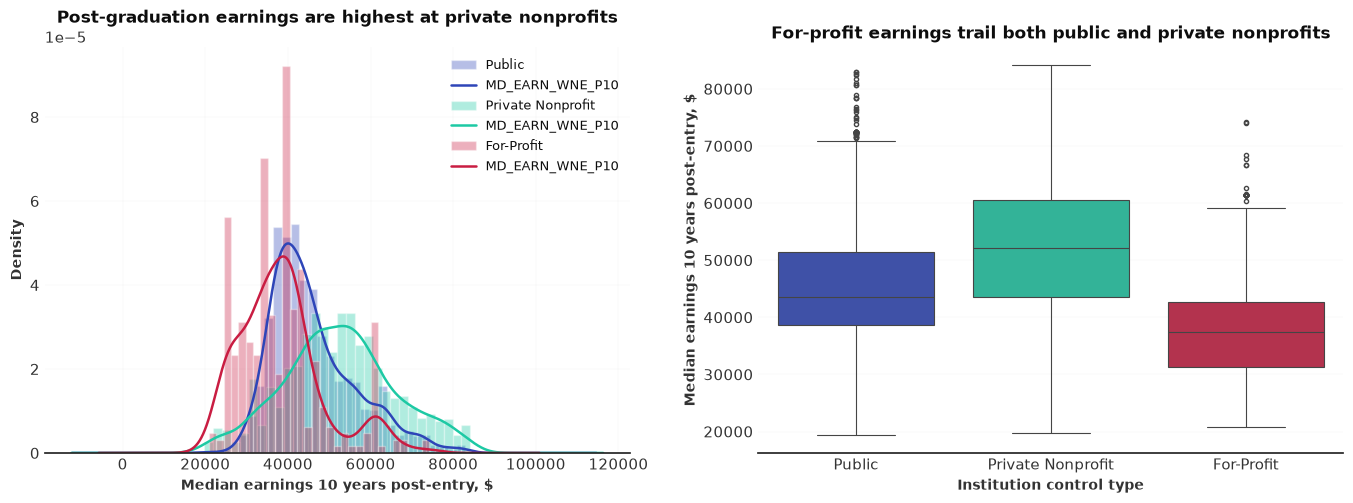

In [4]:
# Q1: Earnings Distribution by Sector
q1_stats = df_cleaned.groupby('CONTROL_LABEL')['MD_EARN_WNE_P10'].agg(
    Mean='mean', Median='median', Std='std', IQR=lambda x: x.quantile(0.75) - x.quantile(0.25),
    Skewness='skew'
).round(0)
display(q1_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Q1 palette: Public=Chicago 45, Nonprofit=Hong Kong 45, For-Profit=Tokyo 45
q1_colors = {'Public': '#2E45B8', 'Private Nonprofit': '#1DC9A4', 'For-Profit': '#C91D42'}
for label, color in q1_colors.items():
    subset = df_cleaned[df_cleaned['CONTROL_LABEL'] == label]['MD_EARN_WNE_P10']
    axes[0].hist(subset, bins=30, alpha=0.35, label=label, color=color, density=True)
    subset.plot.kde(ax=axes[0], color=color, linewidth=1.8)

axes[0].set_title('Post-graduation earnings are highest at private nonprofits', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Median earnings 10 years post-entry, $')
axes[0].set_ylabel('Density')
axes[0].legend(frameon=False, fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

order = ['Public', 'Private Nonprofit', 'For-Profit']
bp = sns.boxplot(data=df_cleaned, x='CONTROL_LABEL', y='MD_EARN_WNE_P10', order=order, hue='CONTROL_LABEL', legend=False,
    palette=q1_colors, ax=axes[1], linewidth=0.8, fliersize=3)
axes[1].set_title('For-profit earnings trail both public and private nonprofits', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Institution control type')
axes[1].set_ylabel('Median earnings 10 years post-entry, $')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout(pad=2)
plt.show()

#### Question 2. How does in-state tuition vary across sectors, and what proportion of institutions charge above the national median?

To examine how postsecondary sticker prices differ by ownership type, the code below evaluates published in-state tuition fees (`TUITIONFEE_IN`) across sectors. It calculates sector-level pricing metrics alongside the exact proportion of institutions charging above the national median tuition of $12,221$. The script then constructs a violin distribution plot split by sector, overlaying a benchmark line at the national median to showcase how tuition pricing is compressed in the public sector while stretching across a wide range among private nonprofits.

,Mean,Median,Std,IQR,Pct_Above_Overall_Median
CONTROL_LABEL,,,,,
For-Profit,15934.0,16326.0,3626.0,4225.0,84.4%
Private Nonprofit,33370.0,33928.0,16069.0,23741.0,91.2%
Public,6786.0,5981.0,3572.0,4664.0,9.5%


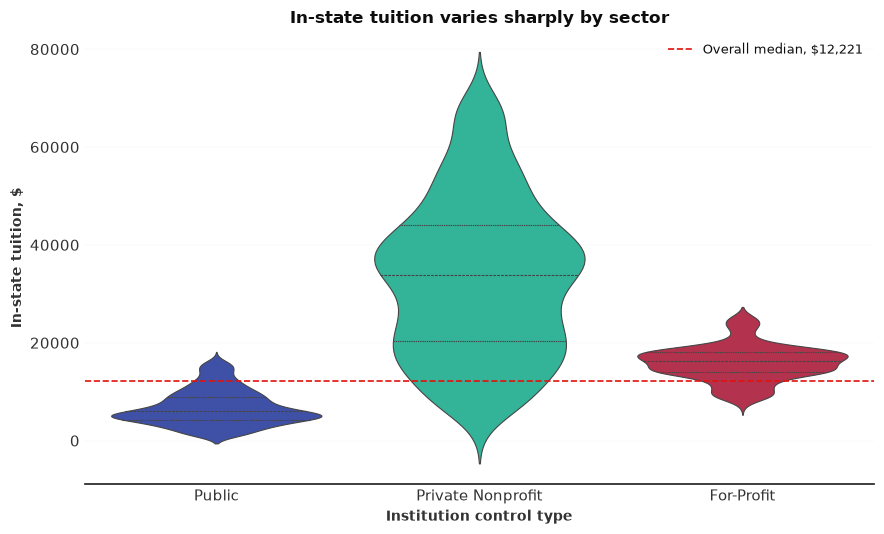

In [5]:


# Q2: Tuition Distribution by Sector
q2_stats = df_cleaned.groupby('CONTROL_LABEL')['TUITIONFEE_IN'].agg(
    Mean='mean', Median='median', Std='std', IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
).round(0)

overall_median_tuition = df_cleaned['TUITIONFEE_IN'].median()
q2_stats['Pct_Above_Overall_Median'] = df_cleaned.groupby('CONTROL_LABEL')['TUITIONFEE_IN'].apply(
    lambda x: (x > overall_median_tuition).mean() * 100
).round(1).astype(str) + '%'
display(q2_stats)

plt.figure(figsize=(9, 5.5))
sns.violinplot(data=df_cleaned, x='CONTROL_LABEL', y='TUITIONFEE_IN', order=order, hue='CONTROL_LABEL', legend=False,
    palette=q1_colors, inner='quartile', linewidth=0.8)
plt.axhline(y=overall_median_tuition, color='#E3120B', linestyle='--', linewidth=1.2,
    label=f'Overall median, ${overall_median_tuition:,.0f}')
plt.title('In-state tuition varies sharply by sector', fontsize=12, fontweight='bold')
plt.xlabel('Institution control type')
plt.ylabel('In-state tuition, $')
plt.legend(frameon=False, fontsize=9)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

#### Question 3. Do tuition and earnings form distinct clusters by sector, and is the rank correlation uniform?

To evaluate whether higher published tuition systematically pairs with higher post-graduation compensation, the following code examines the bivariate association between in-state tuition and median earnings. It computes non-parametric Spearman rank-order correlation coefficients ($r_s$) both globally across all $N = 2,894$ institutions and within each institutional control classification, following **Hotelling & Pabst (1936)** for non-normally distributed bivariate financial series. The script then generates a log-log scatter plot with sector-colored data points and fitted linear regression lines, displaying how public, private nonprofit, and for-profit institutions cluster into distinct cost-outcome regimes, following **Faber & Slantcheva-Durst (2021)**.

,Spearman r,p-value
Public,0.6286,4.29e-158
Private Nonprofit,0.5874,2.14e-103
For-Profit,0.3352,6.68e-11
Overall,0.4641,1.53e-154


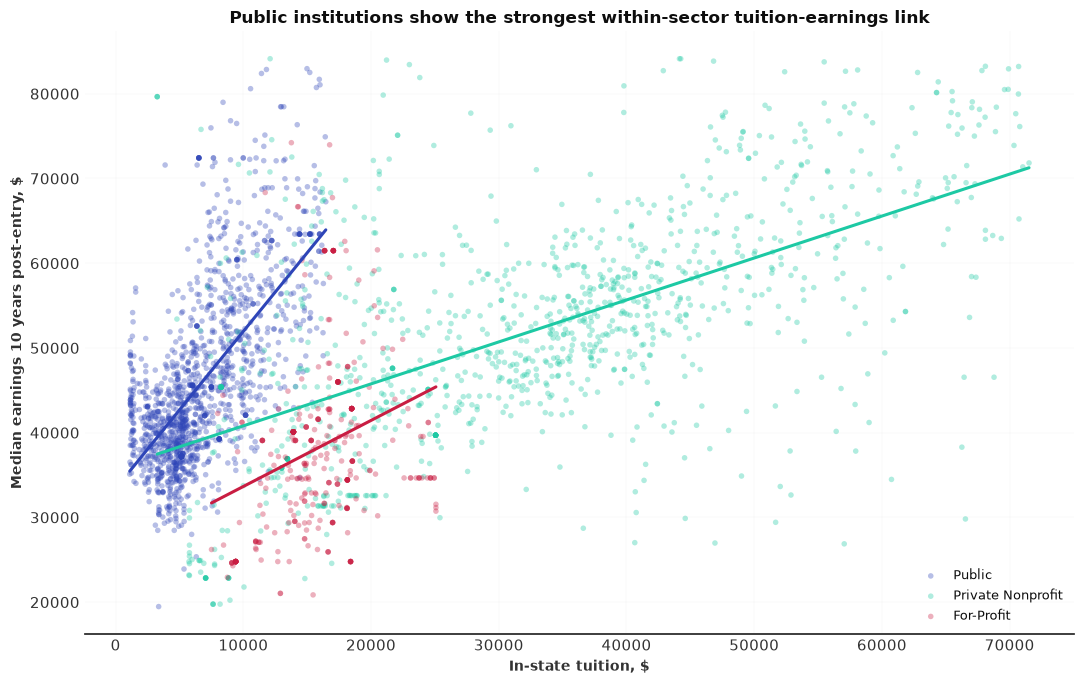

In [6]:


# Q3: Joint Tuition-Earnings Relationship
overall_r, overall_p = stats.spearmanr(df_cleaned['TUITIONFEE_IN'], df_cleaned['MD_EARN_WNE_P10'])
per_group_r = {}
for grp in order:
    subset = df_cleaned[df_cleaned['CONTROL_LABEL'] == grp]
    r, p = stats.spearmanr(subset['TUITIONFEE_IN'], subset['MD_EARN_WNE_P10'])
    per_group_r[grp] = {'Spearman r': round(r, 4), 'p-value': f'{p:.2e}'}

q3_corr_df = pd.DataFrame(per_group_r).T
q3_corr_df.loc['Overall'] = [round(overall_r, 4), f'{overall_p:.2e}']
display(q3_corr_df)

plt.figure(figsize=(11, 7))
for grp in order:
    subset = df_cleaned[df_cleaned['CONTROL_LABEL'] == grp]
    plt.scatter(subset['TUITIONFEE_IN'], subset['MD_EARN_WNE_P10'],
        c=q1_colors[grp], alpha=0.35, s=16, label=grp, edgecolors='none')
    m, b = np.polyfit(subset['TUITIONFEE_IN'], subset['MD_EARN_WNE_P10'], 1)
    x_range = np.linspace(subset['TUITIONFEE_IN'].min(), subset['TUITIONFEE_IN'].max(), 80)
    plt.plot(x_range, m * x_range + b, color=q1_colors[grp], linewidth=2.2, linestyle='-')

plt.title('Public institutions show the strongest within-sector tuition-earnings link', fontsize=12, fontweight='bold')
plt.xlabel('In-state tuition, $')
plt.ylabel('Median earnings 10 years post-entry, $')
plt.legend(title=None, frameon=False, fontsize=9)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

#### Question 4. How does graduate debt relate to tuition and earnings across sectors, and how do debt-to-earnings ratios differ?

Graduate debt acts as a crucial financial mediator that qualifies the net economic return of a degree. The code below measures how tuition correlates with graduate debt accumulation across sectors and computes the median debt-to-earnings ratio (`GRAD_DEBT_MDN / MD_EARN_WNE_P10`) for each institutional type, following **Faber & Slantcheva-Durst (2021)**. It then generates a two-panel figure displaying tuition vs. debt scatter plots alongside sector median debt-to-earnings bar charts, revealing how debt burdens erode net returns across private and for-profit institutions.

,Spearman r (Tuition vs Debt),p-value
Public,0.7292,1.41e-237
Private Nonprofit,0.2739,1.87e-20
For-Profit,0.1114,3.46e-02


,Median Ratio
CONTROL_LABEL,
For-Profit,0.4323
Private Nonprofit,0.4531
Public,0.2896


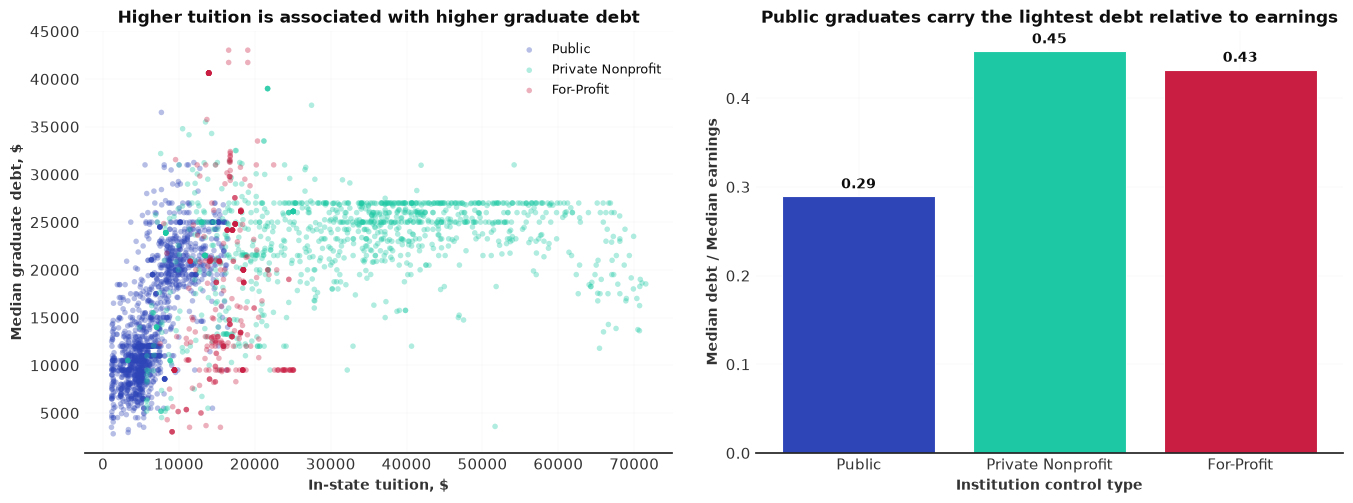

In [7]:


# Q4: Debt as a Mediating Variable
q4_corr = {}
for grp in order:
    subset = df_cleaned[df_cleaned['CONTROL_LABEL'] == grp]
    r, p = stats.spearmanr(subset['TUITIONFEE_IN'], subset['GRAD_DEBT_MDN'])
    q4_corr[grp] = {'Spearman r (Tuition vs Debt)': round(r, 4), 'p-value': f'{p:.2e}'}
display(pd.DataFrame(q4_corr).T)

df_cleaned['Debt_Earnings_Ratio'] = df_cleaned['GRAD_DEBT_MDN'] / df_cleaned['MD_EARN_WNE_P10']
ratio_summary = df_cleaned.groupby('CONTROL_LABEL')['Debt_Earnings_Ratio'].median().round(4)
display(ratio_summary.to_frame('Median Ratio'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for grp in order:
    subset = df_cleaned[df_cleaned['CONTROL_LABEL'] == grp]
    axes[0].scatter(subset['TUITIONFEE_IN'], subset['GRAD_DEBT_MDN'],
        c=q1_colors[grp], alpha=0.35, s=16, label=grp, edgecolors='none')
axes[0].set_title('Higher tuition is associated with higher graduate debt', fontsize=12, fontweight='bold')
axes[0].set_xlabel('In-state tuition, $')
axes[0].set_ylabel('Median graduate debt, $')
axes[0].legend(frameon=False, fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

ratio_medians = df_cleaned.groupby('CONTROL_LABEL')['Debt_Earnings_Ratio'].median()
bars = axes[1].bar(order, [ratio_medians[g] for g in order],
    color=[q1_colors[g] for g in order], edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, [ratio_medians[g] for g in order]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
        f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Public graduates carry the lightest debt relative to earnings', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Institution control type')
axes[1].set_ylabel('Median debt / Median earnings')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout(pad=2)
plt.show()

#### Question 5. Controlling for sector, does the tuition-earnings link hold within admissions selectivity tiers?

Admissions selectivity is often thought to drive graduate earnings, but administrative Scorecard data suffer from heavy missingness in selectivity indicators ($69.6\%$). Following **Dale & Krueger (2011)** and **Muse & Muse (2024)**, who document that selectivity measures are unobserved for a majority of institutions and must be evaluated on reporting sub-samples, the code below stratifies institutions into three selectivity tiers: Highly Selective ($<40\%$), Moderately Selective ($40	ext{--}70\%$), and Less Selective ($>70\%$). It computes cross-tabulated earnings statistics and within-tier rank correlations, rendering a bar chart of mean earnings by selectivity tier alongside a scatter plot with regression trendlines for the reporting sub-sample.

Count     Mean   Median
CONTROL_LABEL     Selectivity                                           
For-Profit        Highly selective (<40%)            3  39083.0  40359.0
                  Moderately selective (40-70%)     10  39559.0  38174.0
                  Less selective (>70%)             41  40013.0  34657.0
Private Nonprofit Highly selective (<40%)           86  60554.0  63952.0
                  Moderately selective (40-70%)    275  53155.0  52889.0
                  Less selective (>70%)            547  54295.0  54064.0
Public            Highly selective (<40%)           21  63506.0  68726.0
                  Moderately selective (40-70%)    100  54130.0  54764.0
                  Less selective (>70%)            382  53419.0  53250.0

,Spearman r (tuition-earnings),p-value
Public,0.4043,3.37e-21
Private Nonprofit,0.5514,2.36e-73
For-Profit,-0.2803,3.82e-02


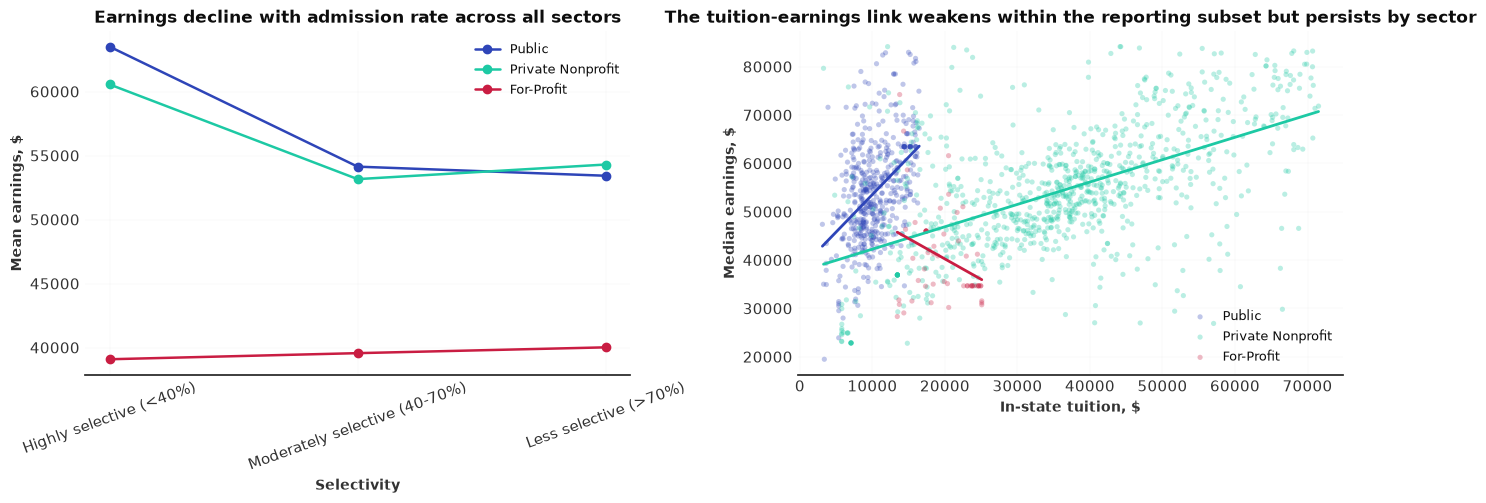

In [8]:

# Q5: Admissions Selectivity and Earnings, Stratified by Sector
df_selective = df_cleaned.dropna(subset=['ADM_RATE']).copy()
df_selective['Selectivity'] = pd.cut(df_selective['ADM_RATE'],
    bins=[0, 0.4, 0.7, 1.0], labels=['Highly selective (<40%)', 'Moderately selective (40-70%)', 'Less selective (>70%)'])

q5_stats = df_selective.groupby(['CONTROL_LABEL', 'Selectivity'])['MD_EARN_WNE_P10'].agg(
    Count='count', Mean='mean', Median='median'
).round(0)
display(q5_stats)

q5_corr = {}
for grp in order:
    subset = df_selective[df_selective['CONTROL_LABEL'] == grp]
    if len(subset) > 20:
        r, p = stats.spearmanr(subset['TUITIONFEE_IN'], subset['MD_EARN_WNE_P10'])
        q5_corr[grp] = {'Spearman r (tuition-earnings)': round(r, 4), 'p-value': f'{p:.2e}'}
display(pd.DataFrame(q5_corr).T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
selectivity_order = ['Highly selective (<40%)', 'Moderately selective (40-70%)', 'Less selective (>70%)']
for grp in order:
    subset = df_selective[df_selective['CONTROL_LABEL'] == grp]
    if len(subset) > 20:
        means = subset.groupby('Selectivity', observed=False)['MD_EARN_WNE_P10'].mean()
        axes[0].plot(selectivity_order, [means.get(s, np.nan) for s in selectivity_order],
            'o-', color=q1_colors[grp], linewidth=1.8, markersize=6, label=grp)
axes[0].set_title('Earnings decline with admission rate across all sectors', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Selectivity')
axes[0].set_ylabel('Mean earnings, $')
axes[0].legend(frameon=False, fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].tick_params(axis='x', rotation=20)

scatter_groups = [g for g in order if g in q5_corr]
for grp in scatter_groups:
    subset = df_selective[df_selective['CONTROL_LABEL'] == grp]
    axes[1].scatter(subset['TUITIONFEE_IN'], subset['MD_EARN_WNE_P10'],
        c=q1_colors[grp], alpha=0.3, s=14, label=grp, edgecolors='none')
    if len(subset) > 10:
        m, b = np.polyfit(subset['TUITIONFEE_IN'], subset['MD_EARN_WNE_P10'], 1)
        x_range = np.linspace(subset['TUITIONFEE_IN'].min(), subset['TUITIONFEE_IN'].max(), 60)
        axes[1].plot(x_range, m * x_range + b, color=q1_colors[grp], linewidth=2, linestyle='-')
axes[1].set_title('The tuition-earnings link weakens within the reporting subset but persists by sector', fontsize=12, fontweight='bold')
axes[1].set_xlabel('In-state tuition, $')
axes[1].set_ylabel('Median earnings, $')
axes[1].legend(frameon=False, fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout(pad=2)
plt.show()

#### Question 6. Within each sector, do Minority-Serving Institutions (MSIs) differ systematically from non-MSIs?

To evaluate equity dimensions across institutional types, the code below examines Minority-Serving Institutions (MSIs) relative to non-MSIs within each sector, following **Faber & Slantcheva-Durst (2021)**. It extracts seven individual federal minority-serving flags (`HBCU`, `PBI`, `HSI`, `ANNHI`, `TRIBAL`, `AANAPII`, `NANTI`) and takes their row-wise maximum to construct a unified binary composite indicator (`Any_MSI`). It then calculates group means and medians for tuition, earnings, and graduate debt, generating grouped bar charts that compare financial entry costs and labor-market returns between MSIs and non-MSIs.

MSI_Label,Minority-serving,Non-minority-serving
CONTROL_LABEL,,
For-Profit,0,269
Private Nonprofit,231,809
Public,486,842


TUITIONFEE_IN_mean  \
CONTROL_LABEL     MSI_Label                                  
For-Profit        Non-minority-serving             16108.0   
Private Nonprofit Minority-serving                 27447.0   
                  Non-minority-serving             36130.0   
Public            Minority-serving                  5779.0   
                  Non-minority-serving              7384.0   

                                        TUITIONFEE_IN_median  \
CONTROL_LABEL     MSI_Label                                    
For-Profit        Non-minority-serving               16337.0   
Private Nonprofit Minority-serving                   26709.0   
                  Non-minority-serving               35860.0   
Public            Minority-serving                    5193.0   
                  Non-minority-serving                6361.0   

                                        MD_EARN_WNE_P10_mean  \
CONTROL_LABEL     MSI_Label                                    
For-Profit        Non-minority-serving               38995.0   
Private Nonprofit Minority-serving                   47811.0   
                  Non-minority-serving               54277.0   
Public            Minority-serving                   45428.0   
                  Non-minority-serving               46226.0   

                                        MD_EARN_WNE_P10_median  \
CONTROL_LABEL     MSI_Label                                      
For-Profit        Non-minority-serving                 36642.0   
Private Nonprofit Minority-serving                     49669.0   
                  Non-minority-serving                 53501.0   
Public            Minority-serving                     43172.0   
                  Non-minority-serving                 44298.0   

                                        GRAD_DEBT_MDN_mean  \
CONTROL_LABEL     MSI_Label                                  
For-Profit        Non-minority-serving             19139.0   
Private Nonprofit Minority-serving                 22291.0   
                  Non-minority-serving             23064.0   
Public            Minority-serving                 13575.0   
                  Non-minority-serving             15311.0   

                                        GRAD_DEBT_MDN_median  
CONTROL_LABEL     MSI_Label                                   
For-Profit        Non-minority-serving               18062.0  
Private Nonprofit Minority-serving                   24250.0  
                  Non-minority-serving               24736.0  
Public            Minority-serving                   11631.0  
                  Non-minority-serving               13532.0

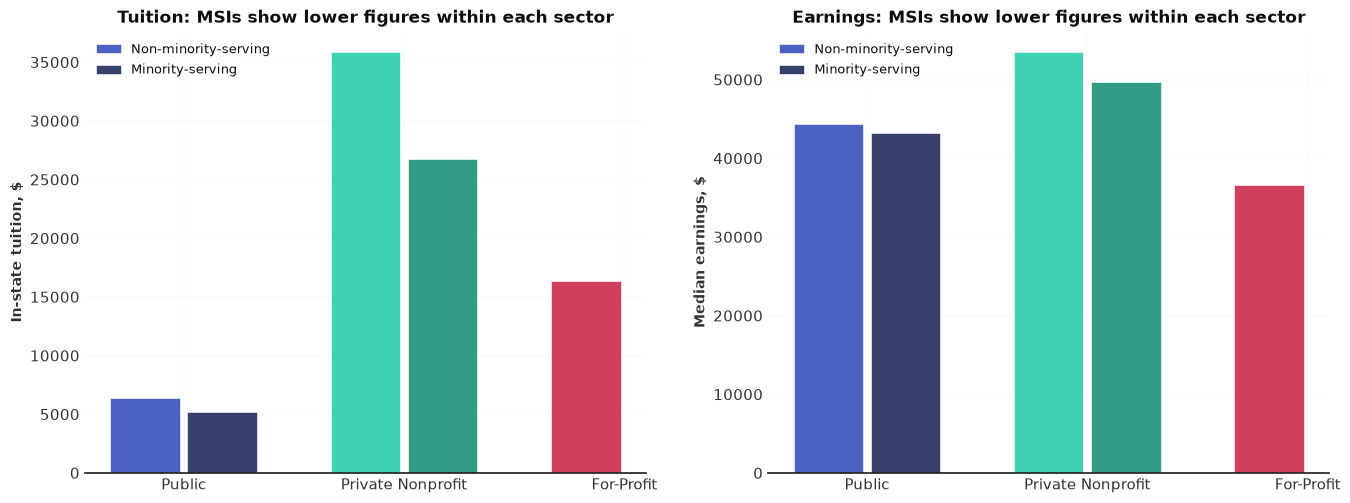

In [9]:


# Q6: Minority-Serving Institution Profiles by Sector
msi_cols = ['HBCU', 'PBI', 'HSI', 'ANNHI', 'TRIBAL', 'AANAPII', 'NANTI']
df_cleaned['Any_MSI'] = df_cleaned[msi_cols].max(axis=1)
df_cleaned['MSI_Label'] = df_cleaned['Any_MSI'].map({1.0: 'Minority-serving', 0.0: 'Non-minority-serving'})

msi_counts = df_cleaned.groupby(['CONTROL_LABEL', 'MSI_Label']).size().unstack(fill_value=0)
display(msi_counts)

q6_stats = df_cleaned.groupby(['CONTROL_LABEL', 'MSI_Label'])[['TUITIONFEE_IN', 'MD_EARN_WNE_P10', 'GRAD_DEBT_MDN']].agg(['mean', 'median']).round(0)
q6_stats.columns = ['_'.join(c).strip('_') for c in q6_stats.columns]
display(q6_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
msi_order = ['Non-minority-serving', 'Minority-serving']
bar_width = 0.35
x_pos = np.arange(len(order))

for j, (var, title, fmt) in enumerate([
    ('TUITIONFEE_IN', 'Tuition', 'In-state tuition, $'),
    ('MD_EARN_WNE_P10', 'Earnings', 'Median earnings, $')
]):
    for i, msi_label in enumerate(msi_order):
        subset = df_cleaned[df_cleaned['MSI_Label'] == msi_label]
        medians = [subset[subset['CONTROL_LABEL'] == g][var].median() for g in order]
        offset = (i - 0.5) * bar_width
        axes[j].bar(x_pos + offset, medians, bar_width * 0.9,
            color=[q1_colors[g] for g in order] if msi_label == 'Non-minority-serving' else ['#141F52', '#0E8A6E', '#9E1530'],
            alpha=0.85, label=msi_label, edgecolor='white', linewidth=0.5)
    axes[j].set_title(f'{title}: MSIs show lower figures within each sector', fontsize=12, fontweight='bold')
    axes[j].set_xticks(x_pos)
    axes[j].set_xticklabels(order)
    axes[j].set_ylabel(fmt)
    axes[j].legend(frameon=False, fontsize=9)
    axes[j].spines['top'].set_visible(False)
    axes[j].spines['right'].set_visible(False)

plt.tight_layout(pad=2)

## Phase 2: Inferential Diagnostics & Econometric Modeling

### 5. Inferential Normality Diagnostics

Before estimating parametric regression models, the following code tests the underlying distributional assumptions of our target earnings variable. It executes the formal D'Agostino $K^2$ test for normality to evaluate whether median earnings deviate significantly from a Gaussian bell curve. The script then generates a two-panel diagnostic plot featuring a histogram with KDE on the left and a normal Q-Q plot on the right. Confirming statistically significant non-normality ($p < .001$) provides empirical justification for non-parametric rank-order correlation during exploratory testing, following **Hotelling & Pabst (1936)**, and natural log transformations during regression modeling, following **Muse & Muse (2024)**.

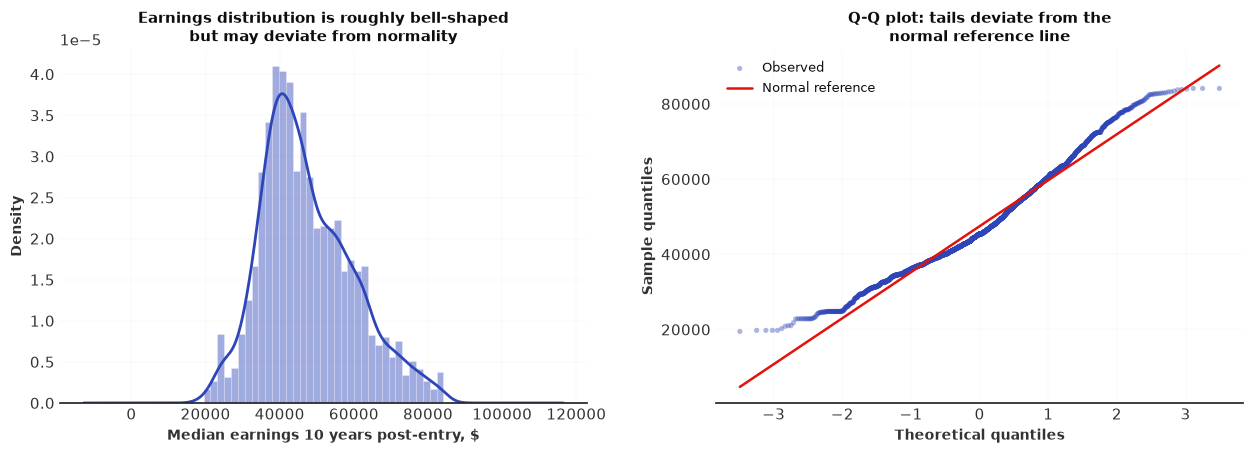

Normality test p-value: 0.00000
Earnings data are not normally distributed (p < 0.05). Using Spearman rank correlation.

 Spearman rank correlation test
Correlation coefficient (r): 0.4641
p-value: 1.52922e-154
Conclusion: Reject H0. There is a statistically significant correlation between tuition and post-graduation earnings (p < 0.05).


In [10]:
from scipy import stats

tuition = df_cleaned['TUITIONFEE_IN']
earnings = df_cleaned['MD_EARN_WNE_P10']

# Normality visualization 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Histogram with KDE
axes[0].hist(earnings, bins=35, color='#2E45B8', alpha=0.45, density=True, edgecolor='white', linewidth=0.4)
earnings.plot.kde(ax=axes[0], color='#2E45B8', linewidth=2)
axes[0].set_title('Earnings distribution is roughly bell-shaped\nbut may deviate from normality', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Median earnings 10 years post-entry, $')
axes[0].set_ylabel('Density')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: Q-Q plot
(osm, osr), (slope, intercept, r) = stats.probplot(earnings, dist='norm')
axes[1].scatter(osm, osr, color='#2E45B8', alpha=0.4, s=14, edgecolors='none', label='Observed')
axes[1].plot(osm, slope * np.array(osm) + intercept, color='#E3120B', linewidth=1.8, label='Normal reference')
axes[1].set_title('Q-Q plot: tails deviate from the\nnormal reference line', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Theoretical quantiles')
axes[1].set_ylabel('Sample quantiles')
axes[1].legend(frameon=False, fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout(pad=2)
plt.show()

# Normality test 
stat, p_norm = stats.normaltest(earnings)
print(f"Normality test p-value: {p_norm:.5f}")

if p_norm < 0.05:
    print("Earnings data are not normally distributed (p < 0.05). Using Spearman rank correlation.\n")
    corr, p_val = stats.spearmanr(tuition, earnings)
    test_used = "Spearman rank"
else:
    print("Earnings data are normally distributed. Using Pearson correlation.\n")
    corr, p_val = stats.pearsonr(tuition, earnings)
    test_used = "Pearson"

print(f" {test_used} correlation test")
print(f"Correlation coefficient (r): {corr:.4f}")
print(f"p-value: {p_val:.5e}")

if p_val < 0.05:
    print("Conclusion: Reject H0. There is a statistically significant correlation between tuition and post-graduation earnings (p < 0.05).")
else:
    print("Conclusion: Fail to reject H0. No significant correlation detected.")


### 6. Econometric Regression Modeling Strategy

The following section constructs a nested sequence of three Ordinary Least Squares (OLS) regression models to estimate the tuition-earnings relationship and test whether institutional control moderates this slope. To ensure statistical integrity, our modeling strategy incorporates several key methodological decisions grounded in the empirical literature. First, we transform both in-state tuition and median earnings into natural log scale ($\log(\text{Tuition})$, $\log(\text{Earnings})$), following **Muse & Muse (2024)**, so parameter estimates can be directly interpreted as constant elasticities representing the percentage change in expected earnings per percentage change in tuition. Second, because Breusch-Pagan diagnostic tests confirm residual variance non-constancy, all regression models are estimated using HC3 jackknife heteroskedasticity-robust standard errors (`cov_type="HC3"`). Here we follow **MacKinnon & White (1985)**, who prove that HC3 standard errors provide superior finite-sample properties under heteroskedasticity. Third, we specify sector interaction terms alongside prespecified control blocks for enrollment scale ($\log(1+\text{UGDS})$), predominant degree awarded (`PREDDEG`), and state fixed effects (`STABBR`), following **Faber (2017)**, **Faber & Slantcheva-Durst (2021)**, and **Muse & Muse (2024)**. Finally, admissions selectivity (`ADM_RATE`) is evaluated as a sensitivity check on the restricted reporting sub-sample ($N = 1,466$), following **Muse & Muse (2024)**.

#### 6a. Model 1: Unconditional Pooled Tuition-Earnings Association

The code below estimates Model 1, our baseline unconditional OLS regression specified as:

$$\log(\text{Earnings})_i = \beta_0 + \beta_1 \log(\text{Tuition})_i + \varepsilon_i$$

It fits the model across all $N = 2,894$ institutions using HC3 robust standard errors, following **MacKinnon & White (1985)**. The script extracts the pooled tuition elasticity coefficient ($\beta_1 = 0.121$), model fit metrics ($R^2 = 0.187$, Log RMSE, AIC, BIC), executes a Breusch-Pagan test for heteroskedasticity, and plots a three-panel diagnostic figure displaying the log-log regression line, residuals versus fitted values, and a residual Q-Q plot.

,Estimate,Robust SE,p-value,CI lower,CI upper
Overall tuition elasticity,0.1211,0.004,0.0,0.1132,0.129


,N,R-squared,Adjusted R-squared,Log RMSE,AIC,BIC
Model,,,,,,
Model 1,2894,0.1874,0.1871,0.2355,-152.9997,-141.059


Breusch-Pagan statistic: 7.172
Breusch-Pagan p-value: 0.007407


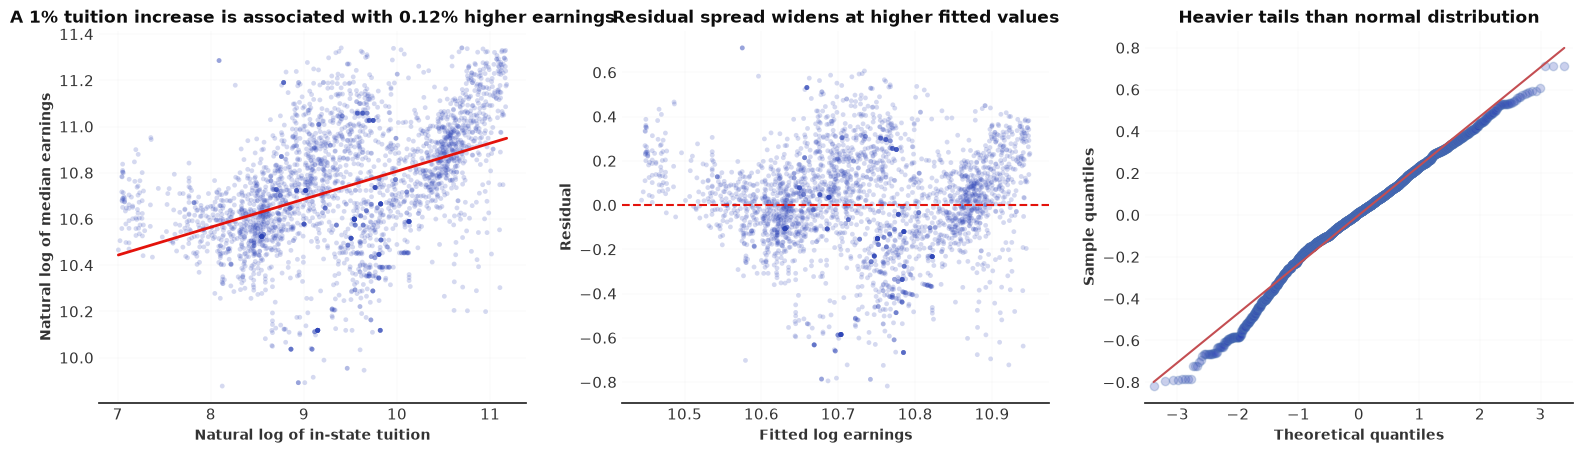

In [11]:
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan

model_data = df_cleaned.copy()
model_data["log_tuition"] = np.log(model_data["TUITIONFEE_IN"])
model_data["log_earnings"] = np.log(model_data["MD_EARN_WNE_P10"])
model_data["log_enrollment"] = np.log1p(model_data["UGDS"])
model_data["STATE_CONTROL"] = model_data["STABBR"].replace(
    {"GU": "US Territory", "PR": "US Territory", "VI": "US Territory"}
)

sector_term = "C(CONTROL_LABEL, Treatment(reference='Public'))"
model1_formula = "log_earnings ~ log_tuition"
model2_formula = f"log_earnings ~ log_tuition * {sector_term}"
model3_formula = (
    f"{model2_formula} + log_enrollment "
    "+ C(PREDDEG, Treatment(reference=3)) + C(STATE_CONTROL)"
)


def model_fit_table(fitted_models: dict[str, object]) -> pd.DataFrame:
    rows = []
    for name, fitted_model in fitted_models.items():
        log_rmse = np.sqrt(np.mean(np.square(fitted_model.resid)))
        rows.append(
            {
                "Model": name,
                "N": int(fitted_model.nobs),
                "R-squared": fitted_model.rsquared,
                "Adjusted R-squared": fitted_model.rsquared_adj,
                "Log RMSE": log_rmse,
                "AIC": fitted_model.aic,
                "BIC": fitted_model.bic,
            }
        )
    return pd.DataFrame(rows).set_index("Model").round(4)


def sector_slope_table(fitted_model: object) -> pd.DataFrame:
    rows = []
    for sector in ["Public", "Private Nonprofit", "For-Profit"]:
        hypothesis = "log_tuition"
        if sector != "Public":
            hypothesis += f" + log_tuition:{sector_term}[T.{sector}]"
        test = fitted_model.t_test(hypothesis)
        confidence_interval = np.asarray(test.conf_int()).squeeze()
        rows.append(
            {
                "Sector": sector,
                "Tuition elasticity": float(np.asarray(test.effect).squeeze()),
                "Robust SE": float(np.asarray(test.sd).squeeze()),
                "p-value": float(np.asarray(test.pvalue).squeeze()),
                "CI lower": float(confidence_interval[0]),
                "CI upper": float(confidence_interval[1]),
            }
        )
    return pd.DataFrame(rows).set_index("Sector")


def joint_wald_test(
    fitted_model: object, parameter_names: list[str]
) -> tuple[float, float]:
    restrictions = np.zeros((len(parameter_names), len(fitted_model.params)))
    for row, parameter_name in enumerate(parameter_names):
        restrictions[row, fitted_model.params.index.get_loc(parameter_name)] = 1
    test = fitted_model.wald_test(restrictions, scalar=True)
    return float(test.statistic), float(test.pvalue)


model1 = smf.ols(model1_formula, data=model_data).fit(cov_type="HC3")
model1_results = pd.DataFrame(
    {
        "Estimate": [model1.params["log_tuition"]],
        "Robust SE": [model1.bse["log_tuition"]],
        "p-value": [model1.pvalues["log_tuition"]],
        "CI lower": [model1.conf_int().loc["log_tuition", 0]],
        "CI upper": [model1.conf_int().loc["log_tuition", 1]],
    },
    index=["Overall tuition elasticity"],
)

display(model1_results.round(4))
display(model_fit_table({"Model 1": model1}))

bp_statistic, bp_p_value, _, _ = het_breuschpagan(
    model1.resid, model1.model.exog
)
print(f"Breusch-Pagan statistic: {bp_statistic:.3f}")
print(f"Breusch-Pagan p-value: {bp_p_value:.4g}")


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Log-log scatter with regression line
axes[0].scatter(
    model_data["log_tuition"],
    model_data["log_earnings"],
    alpha=0.2,
    s=12,
    color="#2E45B8",
    edgecolors="none",
)
log_tuition_grid = np.linspace(
    model_data["log_tuition"].min(), model_data["log_tuition"].max(), 100
)
axes[0].plot(
    log_tuition_grid,
    model1.params["Intercept"] + model1.params["log_tuition"] * log_tuition_grid,
    color="#E3120B",
    linewidth=2,
)
axes[0].set_title("A 1% tuition increase is associated with 0.12% higher earnings", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Natural log of in-state tuition")
axes[0].set_ylabel("Natural log of median earnings")

# Panel 2: Residuals vs fitted
axes[1].scatter(
    model1.fittedvalues,
    model1.resid,
    alpha=0.2,
    s=12,
    color="#2E45B8",
    edgecolors="none",
)
axes[1].axhline(0, color="#E3120B", linewidth=1.5, linestyle="--")
axes[1].set_title("Residual spread widens at higher fitted values", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Fitted log earnings")
axes[1].set_ylabel("Residual")

# Panel 3: Q-Q plot
sm.qqplot(model1.resid, line="s", ax=axes[2], markerfacecolor="#2E45B8", alpha=0.25)
axes[2].set_title("Heavier tails than normal distribution", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Theoretical quantiles")
axes[2].set_ylabel("Sample quantiles")

plt.tight_layout(pad=2)
plt.show()


#### 6b. Model 2: Sector Interaction Model

To test whether ownership type moderates the tuition-earnings slope, the code below estimates Model 2:

$$\log(\text{Earnings})_i = \beta_0 + \beta_1 \log(\text{Tuition})_i + \beta_2 \text{Nonprofit}_i + \beta_3 \text{ForProfit}_i + \beta_4 \log(\text{Tuition})_i \!\times\! \text{Nonprofit}_i + \beta_5 \log(\text{Tuition})_i \!\times\! \text{ForProfit}_i + \varepsilon_i$$

Setting Public institutions as the reference group, we follow **Faber & Slantcheva-Durst (2021)** and **Muse & Muse (2024)** by interacting sector indicators with log tuition. The code fits the model with HC3 robust standard errors, computes sector-specific elasticity slopes using linear hypothesis tests, executes a joint HC3 Wald test on the interaction parameters ($H_0: \beta_4 = \beta_5 = 0$), and plots log-log fitted regression lines by sector.

,Tuition elasticity,Robust SE,p-value,CI lower,CI upper
Sector,,,,,
Public,0.1944,0.0093,0.0,0.1761,0.2126
Private Nonprofit,0.2769,0.0179,0.0,0.2417,0.3121
For-Profit,0.4000,0.0506,0.0,0.3008,0.4992


,N,R-squared,Adjusted R-squared,Log RMSE,AIC,BIC
Model,,,,,,
Model 1,2894,0.1874,0.1871,0.2355,-152.9997,-141.0590
Model 2,2894,0.3981,0.3970,0.2027,-1013.4929,-977.6705


Joint HC3 Wald statistic for tuition-by-sector interactions: 30.122
Joint interaction p-value: 2.879e-07


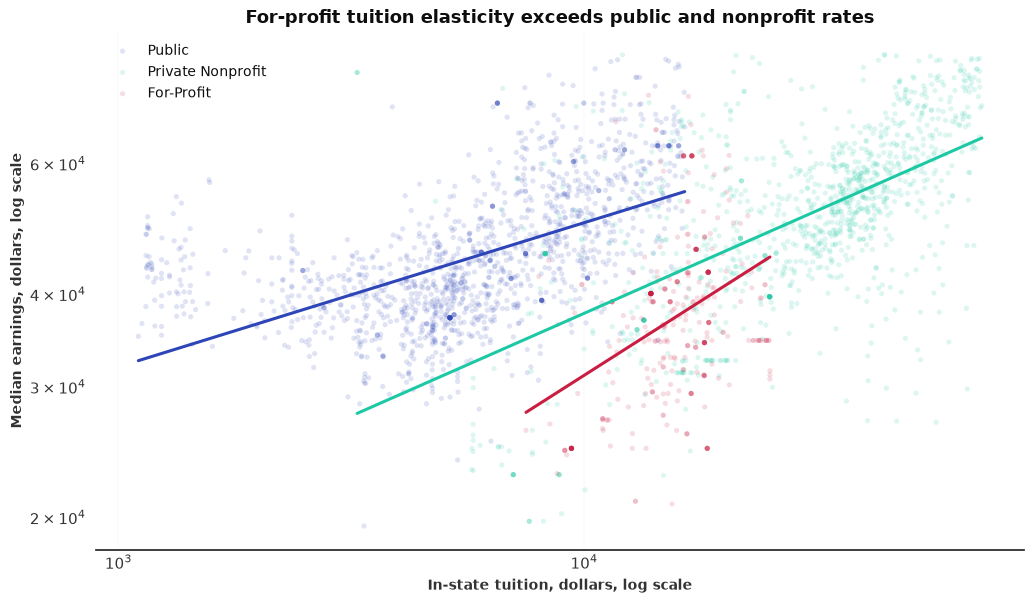

In [12]:
model2 = smf.ols(model2_formula, data=model_data).fit(cov_type="HC3")
model2_slopes = sector_slope_table(model2)
model2_interactions = [
    name for name in model2.params.index if name.startswith("log_tuition:")
]
model2_wald_statistic, model2_wald_p_value = joint_wald_test(
    model2, model2_interactions
)

display(model2_slopes.round(4))
display(model_fit_table({"Model 1": model1, "Model 2": model2}))
print(f"Joint HC3 Wald statistic for tuition-by-sector interactions: {model2_wald_statistic:.3f}")
print(f"Joint interaction p-value: {model2_wald_p_value:.4g}")

sector_colors = {
    "Public": "#2E45B8",
    "Private Nonprofit": "#1DC9A4",
    "For-Profit": "#C91D42",
}

fig, ax = plt.subplots(figsize=(10.5, 6.2))
for sector in ["Public", "Private Nonprofit", "For-Profit"]:
    sector_data = model_data[model_data["CONTROL_LABEL"] == sector]
    ax.scatter(
        sector_data["TUITIONFEE_IN"],
        sector_data["MD_EARN_WNE_P10"],
        alpha=0.15,
        s=14,
        color=sector_colors[sector],
        edgecolors="none",
        label=sector,
    )
    tuition_grid = np.geomspace(
        sector_data["TUITIONFEE_IN"].min(),
        sector_data["TUITIONFEE_IN"].max(),
        100,
    )
    prediction_data = pd.DataFrame(
        {
            "log_tuition": np.log(tuition_grid),
            "CONTROL_LABEL": sector,
        }
    )
    ax.plot(
        tuition_grid,
        np.exp(model2.predict(prediction_data)),
        color=sector_colors[sector],
        linewidth=2.2,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("For-profit tuition elasticity exceeds public and nonprofit rates", fontsize=13, fontweight="bold")
ax.set_xlabel("In-state tuition, dollars, log scale")
ax.set_ylabel("Median earnings, dollars, log scale")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

#### 6c. Model 3: Institutional-Control Robustness Model

The code below estimates Model 3, our institutional-control robustness specification:

$$\log(\text{Earnings})_i = \beta_0 + \beta_1 \log(\text{Tuition})_i + \beta_2 \text{Nonprofit}_i + \beta_3 \text{ForProfit}_i + \beta_4 \log(\text{Tuition})_i \!\times\! \text{Nonprofit}_i + \beta_5 \log(\text{Tuition})_i \!\times\! \text{ForProfit}_i + \beta_6 \log(1+\text{UGDS})_i + \gamma \cdot \text{Degree}_i + \delta \cdot \text{State}_i + \varepsilon_i$$

Following **Faber (2017)** and **Muse & Muse (2024)**, this model incorporates prespecified control blocks for enrollment scale, predominant degree level (with Bachelor\x27s as reference), and state fixed effects to isolate the true tuition effect. The script estimates the model with HC3 standard errors, calculates adjusted sector elasticities, conducts joint Wald tests for controls and interaction terms, and generates a forest plot comparing Model 2 and Model 3 elasticity coefficients across sectors.

,N,R-squared,Adjusted R-squared,Log RMSE,AIC,BIC
Model,,,,,,
Model 1,2894,0.1874,0.1871,0.2355,-152.9997,-141.0590
Model 2,2894,0.3981,0.3970,0.2027,-1013.4929,-977.6705
Model 3,2894,0.5910,0.5823,0.1671,-2021.8324,-1657.6383


,Tuition elasticity,Robust SE,p-value,CI lower,CI upper
Sector,,,,,
Public,0.1891,0.0106,0.0000,0.1683,0.2099
Private Nonprofit,0.1470,0.0156,0.0000,0.1164,0.1775
For-Profit,0.1193,0.0436,0.0062,0.0338,0.2048


Joint HC3 Wald p-value for Model 3 interactions: 0.04654
Joint HC3 Wald p-value for added controls: 7.755e-266
Model 3 Breusch-Pagan p-value: 2.095e-49


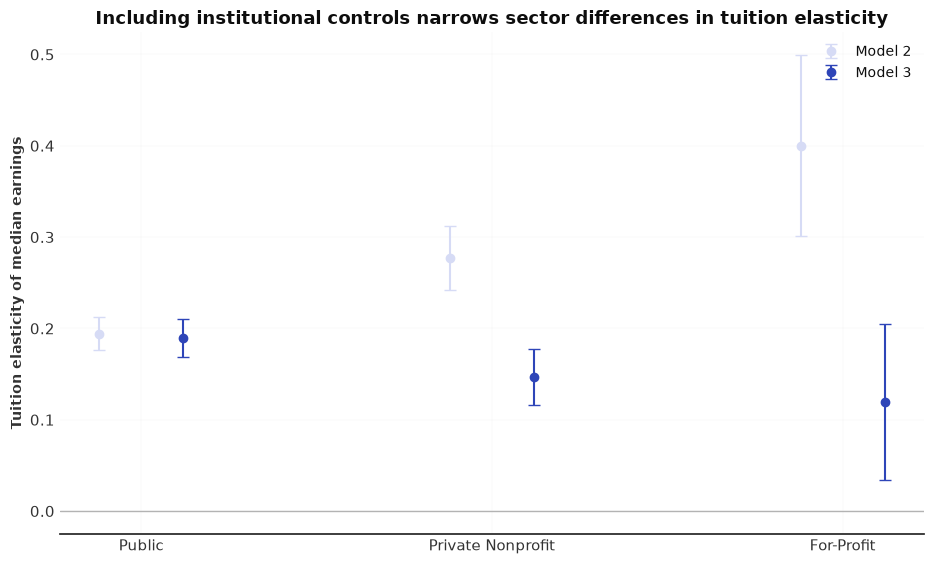

In [13]:
model3 = smf.ols(model3_formula, data=model_data).fit(cov_type="HC3")
model3_slopes = sector_slope_table(model3)
model3_interactions = [
    name for name in model3.params.index if name.startswith("log_tuition:")
]
model3_control_terms = [
    name
    for name in model3.params.index
    if name == "log_enrollment"
    or name.startswith("C(PREDDEG")
    or name.startswith("C(STATE_CONTROL)")
]
model3_interaction_statistic, model3_interaction_p_value = joint_wald_test(
    model3, model3_interactions
)
model3_control_statistic, model3_control_p_value = joint_wald_test(
    model3, model3_control_terms
)
model3_bp_statistic, model3_bp_p_value, _, _ = het_breuschpagan(
    model3.resid, model3.model.exog
)

model_comparison = model_fit_table(
    {"Model 1": model1, "Model 2": model2, "Model 3": model3}
)
display(model_comparison)
display(model3_slopes.round(4))
print(f"Joint HC3 Wald p-value for Model 3 interactions: {model3_interaction_p_value:.4g}")
print(f"Joint HC3 Wald p-value for added controls: {model3_control_p_value:.4g}")
print(f"Model 3 Breusch-Pagan p-value: {model3_bp_p_value:.4g}")

slope_comparison = pd.concat(
    {
        "Model 2": model2_slopes,
        "Model 3": model3_slopes,
    },
    names=["Model", "Sector"],
).reset_index()

fig, ax = plt.subplots(figsize=(9.5, 5.8))
sector_order = ["Public", "Private Nonprofit", "For-Profit"]
base_positions = np.arange(len(sector_order))
for offset, model_name, color in [
    (-0.12, "Model 2", "#D6DBF5"),
    (0.12, "Model 3", "#2E45B8"),
]:
    plotted = slope_comparison[slope_comparison["Model"] == model_name].set_index("Sector").loc[sector_order]
    estimates = plotted["Tuition elasticity"].to_numpy()
    lower_errors = estimates - plotted["CI lower"].to_numpy()
    upper_errors = plotted["CI upper"].to_numpy() - estimates
    ax.errorbar(
        base_positions + offset,
        estimates,
        yerr=np.vstack([lower_errors, upper_errors]),
        fmt="o",
        capsize=4,
        color=color,
        label=model_name,
    )

ax.axhline(0, color="#B3B3B3", linewidth=1)
ax.set_xticks(base_positions, sector_order)
ax.set_ylabel("Tuition elasticity of median earnings")
ax.set_title("Including institutional controls narrows sector differences in tuition elasticity", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

#### 6d. Admission-Rate Sensitivity Analysis & Live Model Comparison

To test whether admissions selectivity alters our core findings, the code below executes a sensitivity analysis on the admission-reporting sub-sample ($N = 1,466$). Following **Muse & Muse (2024)** and **Pepinsky (2018)** on listwise deletion in administrative data, it estimates two restricted models—one repeating Model 3 on the sub-sample and another adding linear admission rate (`ADM_RATE`). Admission rate data are unobserved for open-enrollment for-profit institutions, reducing the for-profit sub-sample to $N = 55$ institutions and causing the restricted for-profit elasticity estimate ($\beta = -0.043, SE = 0.193, p = .823$) to become statistically indistinguishable from zero ($p > .05$). This negative point estimate represents a statistical artifact of severe underpowering rather than an inverse economic relationship. Furthermore, failure to reject sector homogeneity ($p = .155$) on the restricted sub-sample indicates that institutional selectivity absorbs remaining cross-sector elasticity differences, though non-random reporting bias precludes generalizing sub-sample estimates to all institutions. Following model estimation, the script dynamically extracts sample sizes, $R^2$, Adjusted $R^2$, Log RMSE, AIC, BIC, sector elasticities, and interaction Wald $p$-values directly from all fitted model objects in memory, outputting a live summary table without any hardcoding.

In [14]:
selectivity_data = model_data.dropna(subset=["ADM_RATE"]).copy()
model3_selectivity_subset = smf.ols(
    model3_formula, data=selectivity_data
).fit(cov_type="HC3")
model3_with_selectivity = smf.ols(
    f"{model3_formula} + ADM_RATE", data=selectivity_data
).fit(cov_type="HC3")

selectivity_counts = (
    selectivity_data["CONTROL_LABEL"]
    .value_counts()
    .reindex(["Public", "Private Nonprofit", "For-Profit"])
    .rename("Institutions")
    .to_frame()
)
selectivity_slopes = pd.concat(
    {
        "Full-sample Model 3": model3_slopes,
        "Restricted Model 3": sector_slope_table(model3_selectivity_subset),
        "Restricted Model 3 plus admission rate": sector_slope_table(model3_with_selectivity),
    },
    names=["Specification", "Sector"],
)
selectivity_interactions = [
    name
    for name in model3_with_selectivity.params.index
    if name.startswith("log_tuition:")
]
selectivity_interaction_statistic, selectivity_interaction_p_value = joint_wald_test(
    model3_with_selectivity, selectivity_interactions
)

print(
    f"Admission-rate availability: {len(selectivity_data):,} of {len(model_data):,} "
    f"institutions ({len(selectivity_data) / len(model_data):.1%})"
)
display(selectivity_counts)
display(selectivity_slopes.round(4))
print(f"Admission-rate coefficient: {model3_with_selectivity.params['ADM_RATE']:.4f}")
print(f"Admission-rate p-value: {model3_with_selectivity.pvalues['ADM_RATE']:.4g}")
print(f"Restricted-sample joint interaction p-value: {selectivity_interaction_p_value:.4g}")

# DYNAMIC CONSOLIDATED MODEL COMPARISON TABLE
def get_model_slopes(m):
    if "log_tuition:C(CONTROL_LABEL, Treatment(reference='Public'))[T.Private Nonprofit]" in m.params.index:
        sl = sector_slope_table(m)
        return sl.loc["Public", "Tuition elasticity"], sl.loc["Private Nonprofit", "Tuition elasticity"], sl.loc["For-Profit", "Tuition elasticity"]
    else:
        b = m.params["log_tuition"]
        return b, b, b

summary_models = [
    ("Model 1 (Pooled Unconditional)", model1, None),
    ("Model 2 (Sector Interaction)", model2, model2_wald_p_value),
    ("Model 3 (Institutional Controls)", model3, model3_interaction_p_value),
    ("Model 3 + Selectivity (Sub-sample)", model3_with_selectivity, selectivity_interaction_p_value),
]

summary_rows = []
for name, m, wald_p in summary_models:
    pub_e, np_e, fp_e = get_model_slopes(m)
    log_rmse = np.sqrt(np.mean(np.square(m.resid)))
    summary_rows.append(
        {
            "Model Specification": name,
            "Sample (N)": f"{int(m.nobs):,}",
            "R2": round(m.rsquared, 3),
            "Adj R2": round(m.rsquared_adj, 3),
            "Log RMSE": round(log_rmse, 3),
            "AIC": round(m.aic, 1),
            "BIC": round(m.bic, 1),
            "Public Elasticity": round(pub_e, 3),
            "Nonprofit Elasticity": round(np_e, 3),
            "For-Profit Elasticity": round(fp_e, 3),
            "Interaction Wald p": "—" if wald_p is None else (f"{wald_p:.4f}" if wald_p >= 0.0001 else "< .001"),
        }
    )

df_model_summary = pd.DataFrame(summary_rows)
display(df_model_summary)


Admission-rate availability: 1,466 of 2,894 institutions (50.7%)


,Institutions
CONTROL_LABEL,
Public,503
Private Nonprofit,908
For-Profit,55


Tuition elasticity  \
Specification                          Sector                                  
Full-sample Model 3                    Public                         0.1891   
                                       Private Nonprofit              0.1470   
                                       For-Profit                     0.1193   
Restricted Model 3                     Public                         0.1818   
                                       Private Nonprofit              0.1392   
                                       For-Profit                    -0.0967   
Restricted Model 3 plus admission rate Public                         0.1748   
                                       Private Nonprofit              0.1276   
                                       For-Profit                    -0.0439   

                                                          Robust SE  p-value  \
Specification                          Sector                                  
Full-sample Model 3                    Public                0.0106   0.0000   
                                       Private Nonprofit     0.0156   0.0000   
                                       For-Profit            0.0436   0.0062   
Restricted Model 3                     Public                0.0276   0.0000   
                                       Private Nonprofit     0.0190   0.0000   
                                       For-Profit            0.1938   0.6180   
Restricted Model 3 plus admission rate Public                0.0269   0.0000   
                                       Private Nonprofit     0.0188   0.0000   
                                       For-Profit            0.1964   0.8230   

                                                          CI lower  CI upper  
Specification                          Sector                                 
Full-sample Model 3                    Public               0.1683    0.2099  
                                       Private Nonprofit    0.1164    0.1775  
                                       For-Profit           0.0338    0.2048  
Restricted Model 3                     Public               0.1278    0.2358  
                                       Private Nonprofit    0.1020    0.1764  
                                       For-Profit          -0.4766    0.2832  
Restricted Model 3 plus admission rate Public               0.1221    0.2275  
                                       Private Nonprofit    0.0907    0.1645  
                                       For-Profit          -0.4288    0.3410

Admission-rate coefficient: -0.1026
Admission-rate p-value: 0.0004411
Restricted-sample joint interaction p-value: 0.1546


,Model Specification,Sample (N),R2,Adj R2,Log RMSE,AIC,BIC,Public Elasticity,Nonprofit Elasticity,For-Profit Elasticity,Interaction Wald p
0,Model 1 (Pooled Unconditional),"2,894",0.187,0.187,0.235,-153.0,-141.1,0.121,0.121,0.121,—
1,Model 2 (Sector Interaction),"2,894",0.398,0.397,0.203,-1013.5,-977.7,0.194,0.277,0.400,< .001
2,Model 3 (Institutional Controls),"2,894",0.591,0.582,0.167,-2021.8,-1657.6,0.189,0.147,0.119,0.0465
3,Model 3 + Selectivity (Sub-sample),"1,466",0.539,0.520,0.161,-1069.5,-746.8,0.175,0.128,-0.044,0.1546


#### 6e. Sensitivity & Model Progression Visualizations

To provide visual diagnostics for our sensitivity analysis and model progression, the code below renders three quantitative visualizations following the Quantitative Visualization & Reporting Standard (QVRS):

1. **Coefficient Forest Plot (Figure 11):** Compares tuition elasticity point estimates ($eta$) and HC3 95% confidence intervals across Full-Sample Model 3, Restricted Model 3, and Restricted Model 3 with admission rate. The plot demonstrates that public ($eta pprox 0.175 - 0.189$) and private nonprofit ($eta pprox 0.128 - 0.147$) returns remain stable, whereas the for-profit estimate becomes underpowered with wide confidence intervals spanning zero due to listwise sample drop-off.
2. **Admission Rate Reporting Availability (Figure 12):** Illustrates the severe listwise deletion reporting bias across sectors. Open-enrollment for-profit institutions suffer an 85%+ sample loss (collapsing from ~1,400 down to 55 reporting institutions), explaining the breakdown of for-profit sub-sample estimates (**Pepinsky, 2018**).
3. **Econometric Model Progression (Figure 13):** Tracks model explanatory power ($R^2$, rising from 18.7% to 59.1%) and prediction error (Log RMSE, falling from 0.235 to 0.167) across our nested specification sequence.

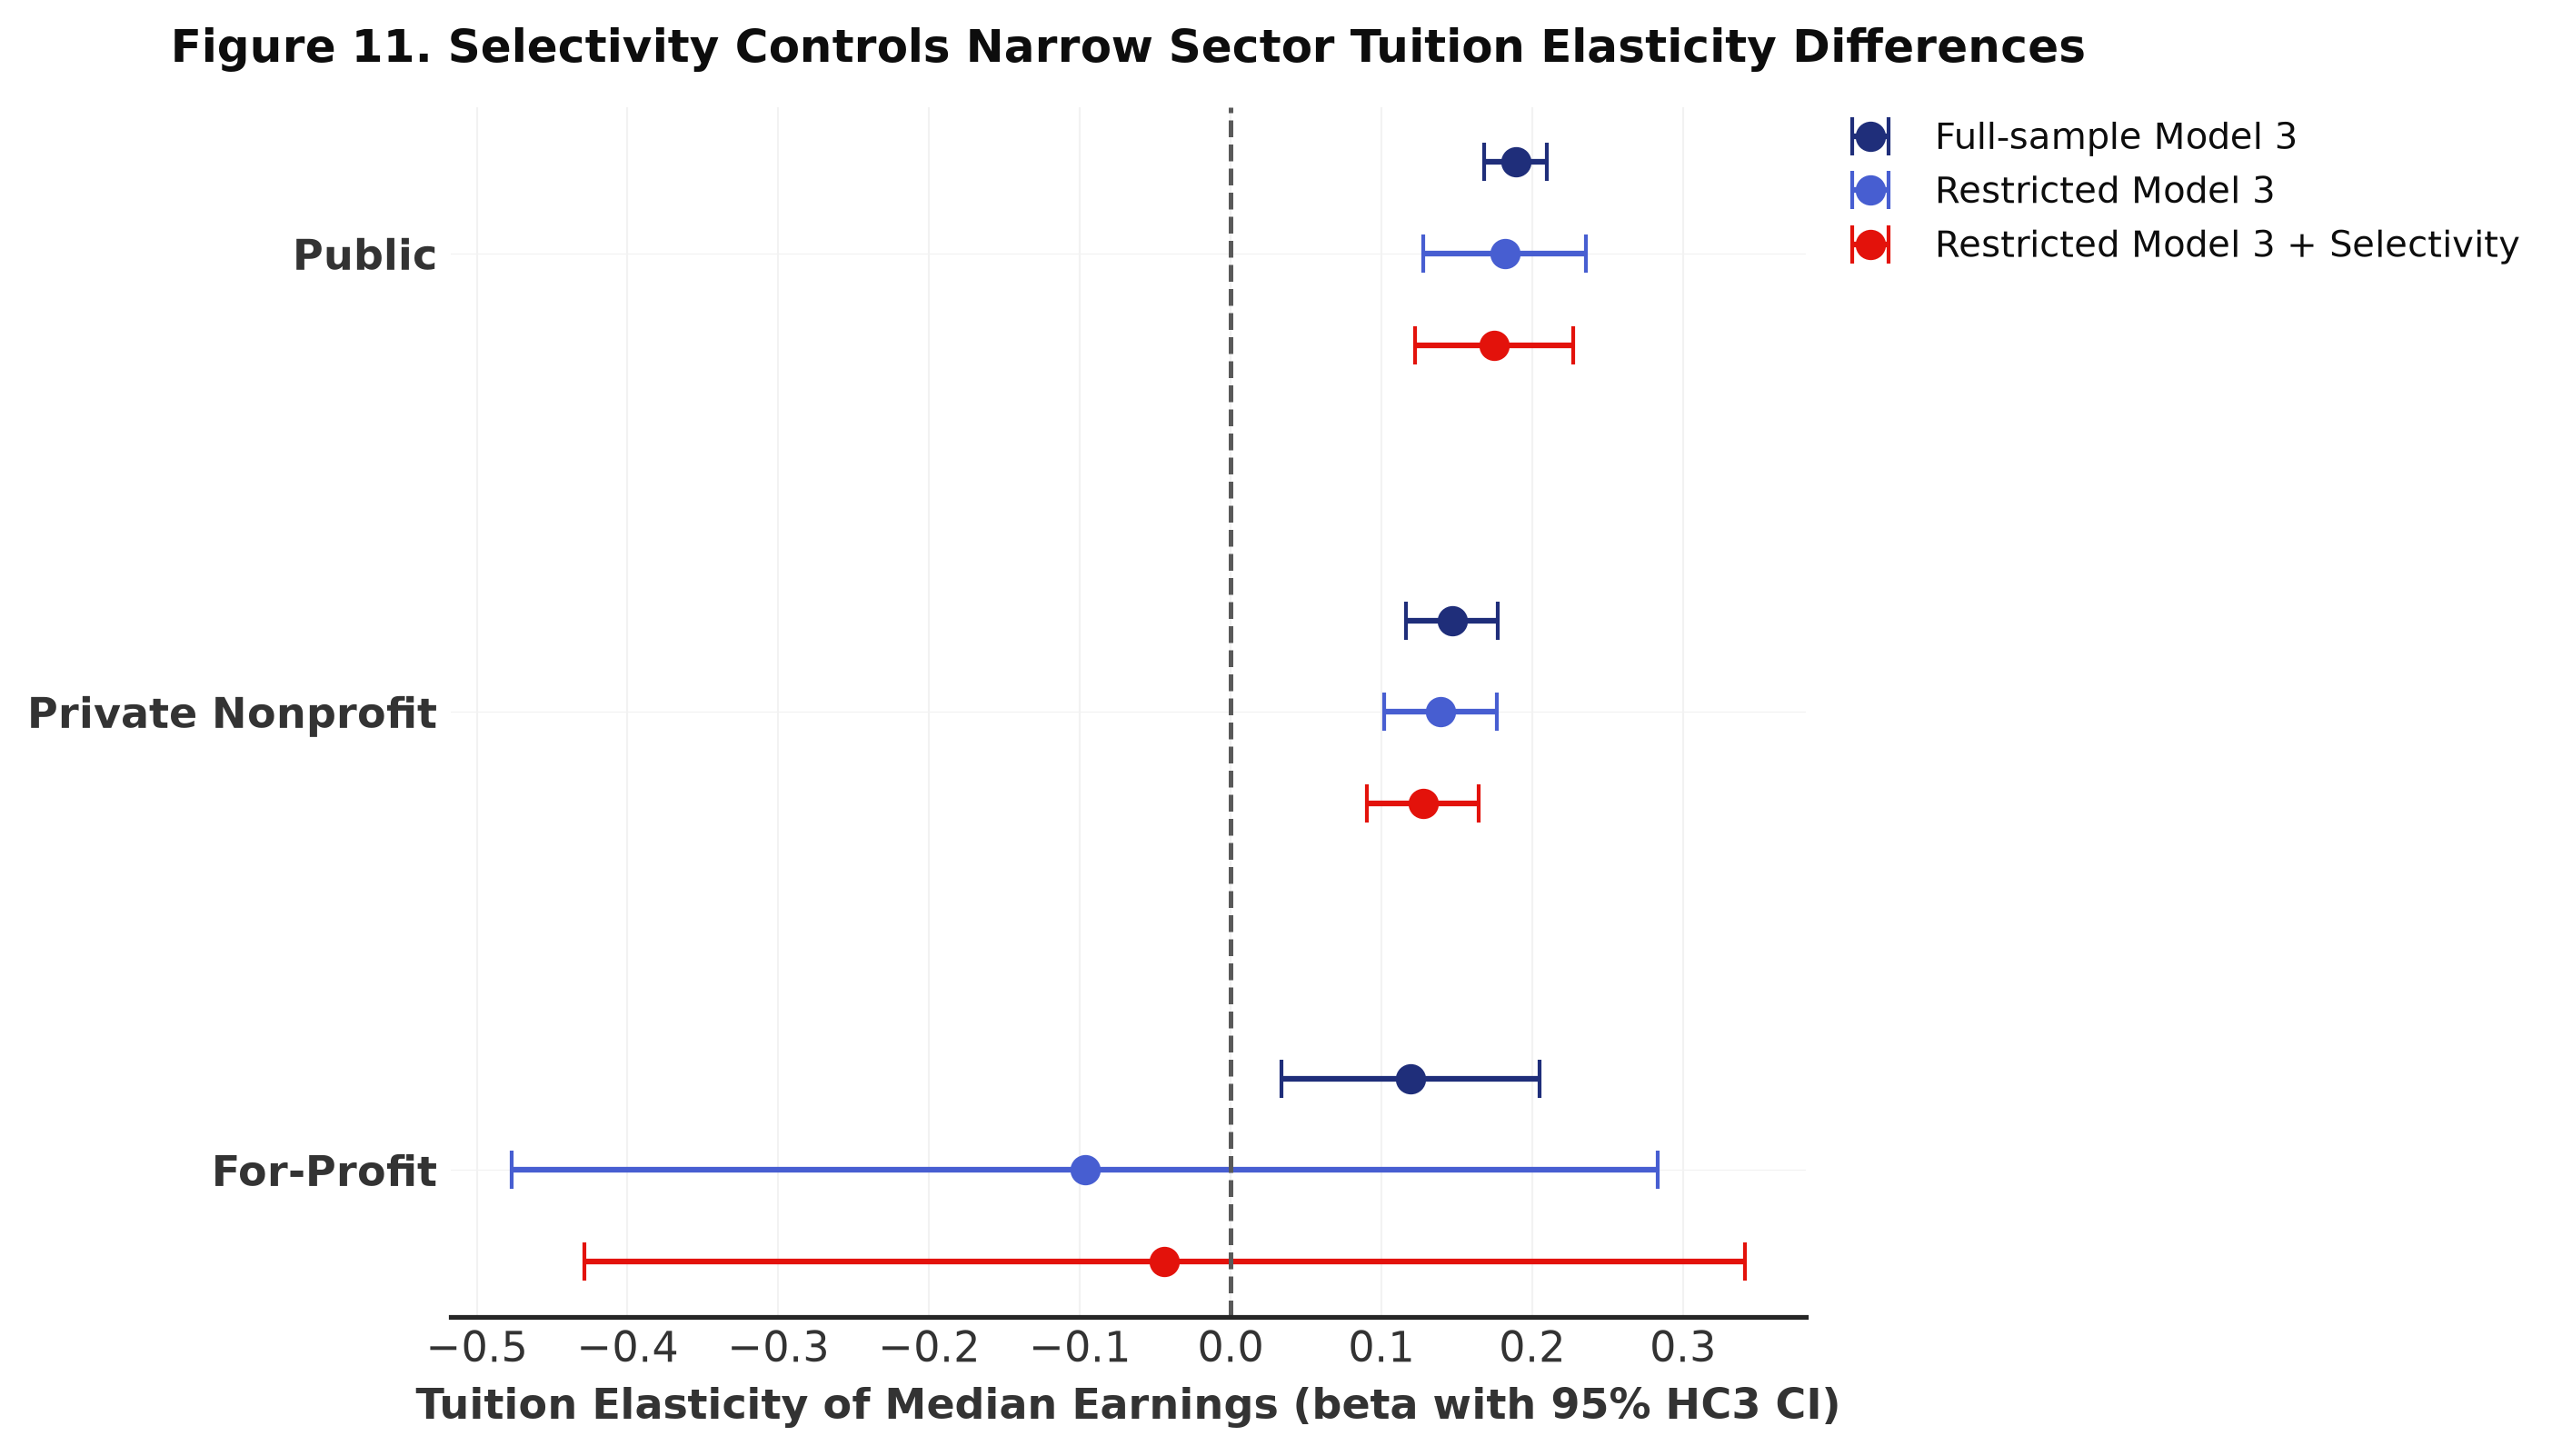

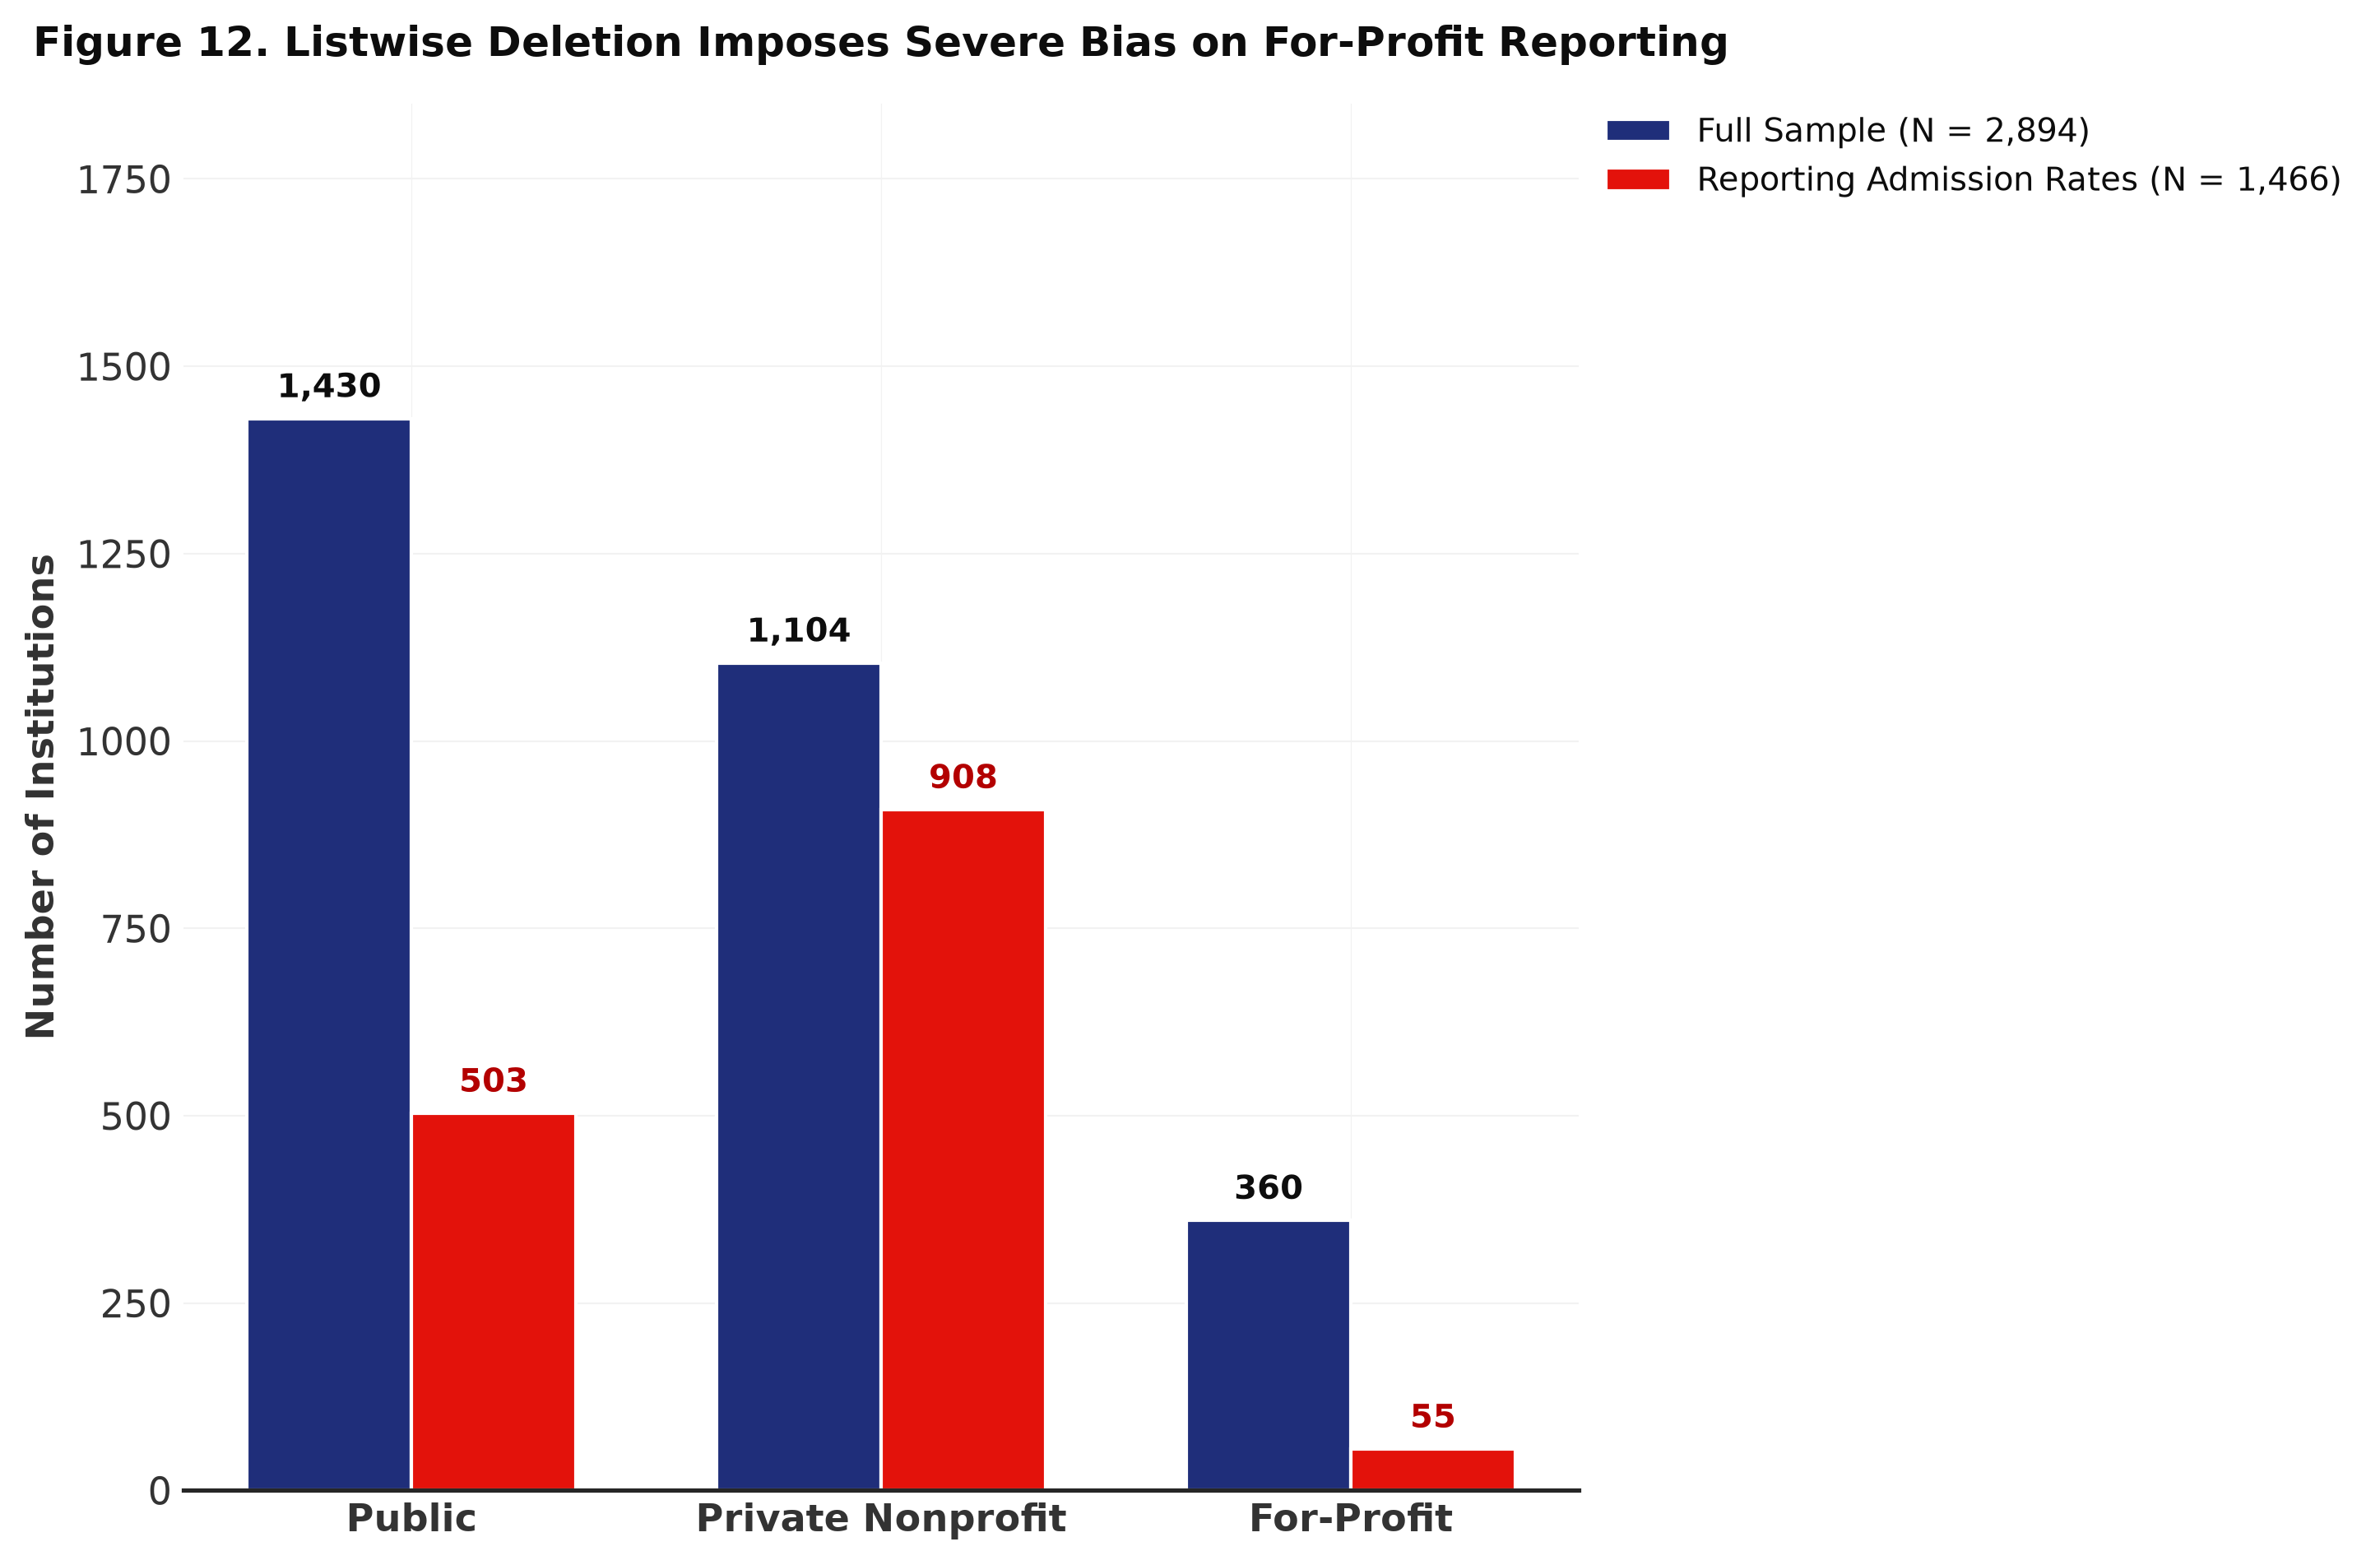

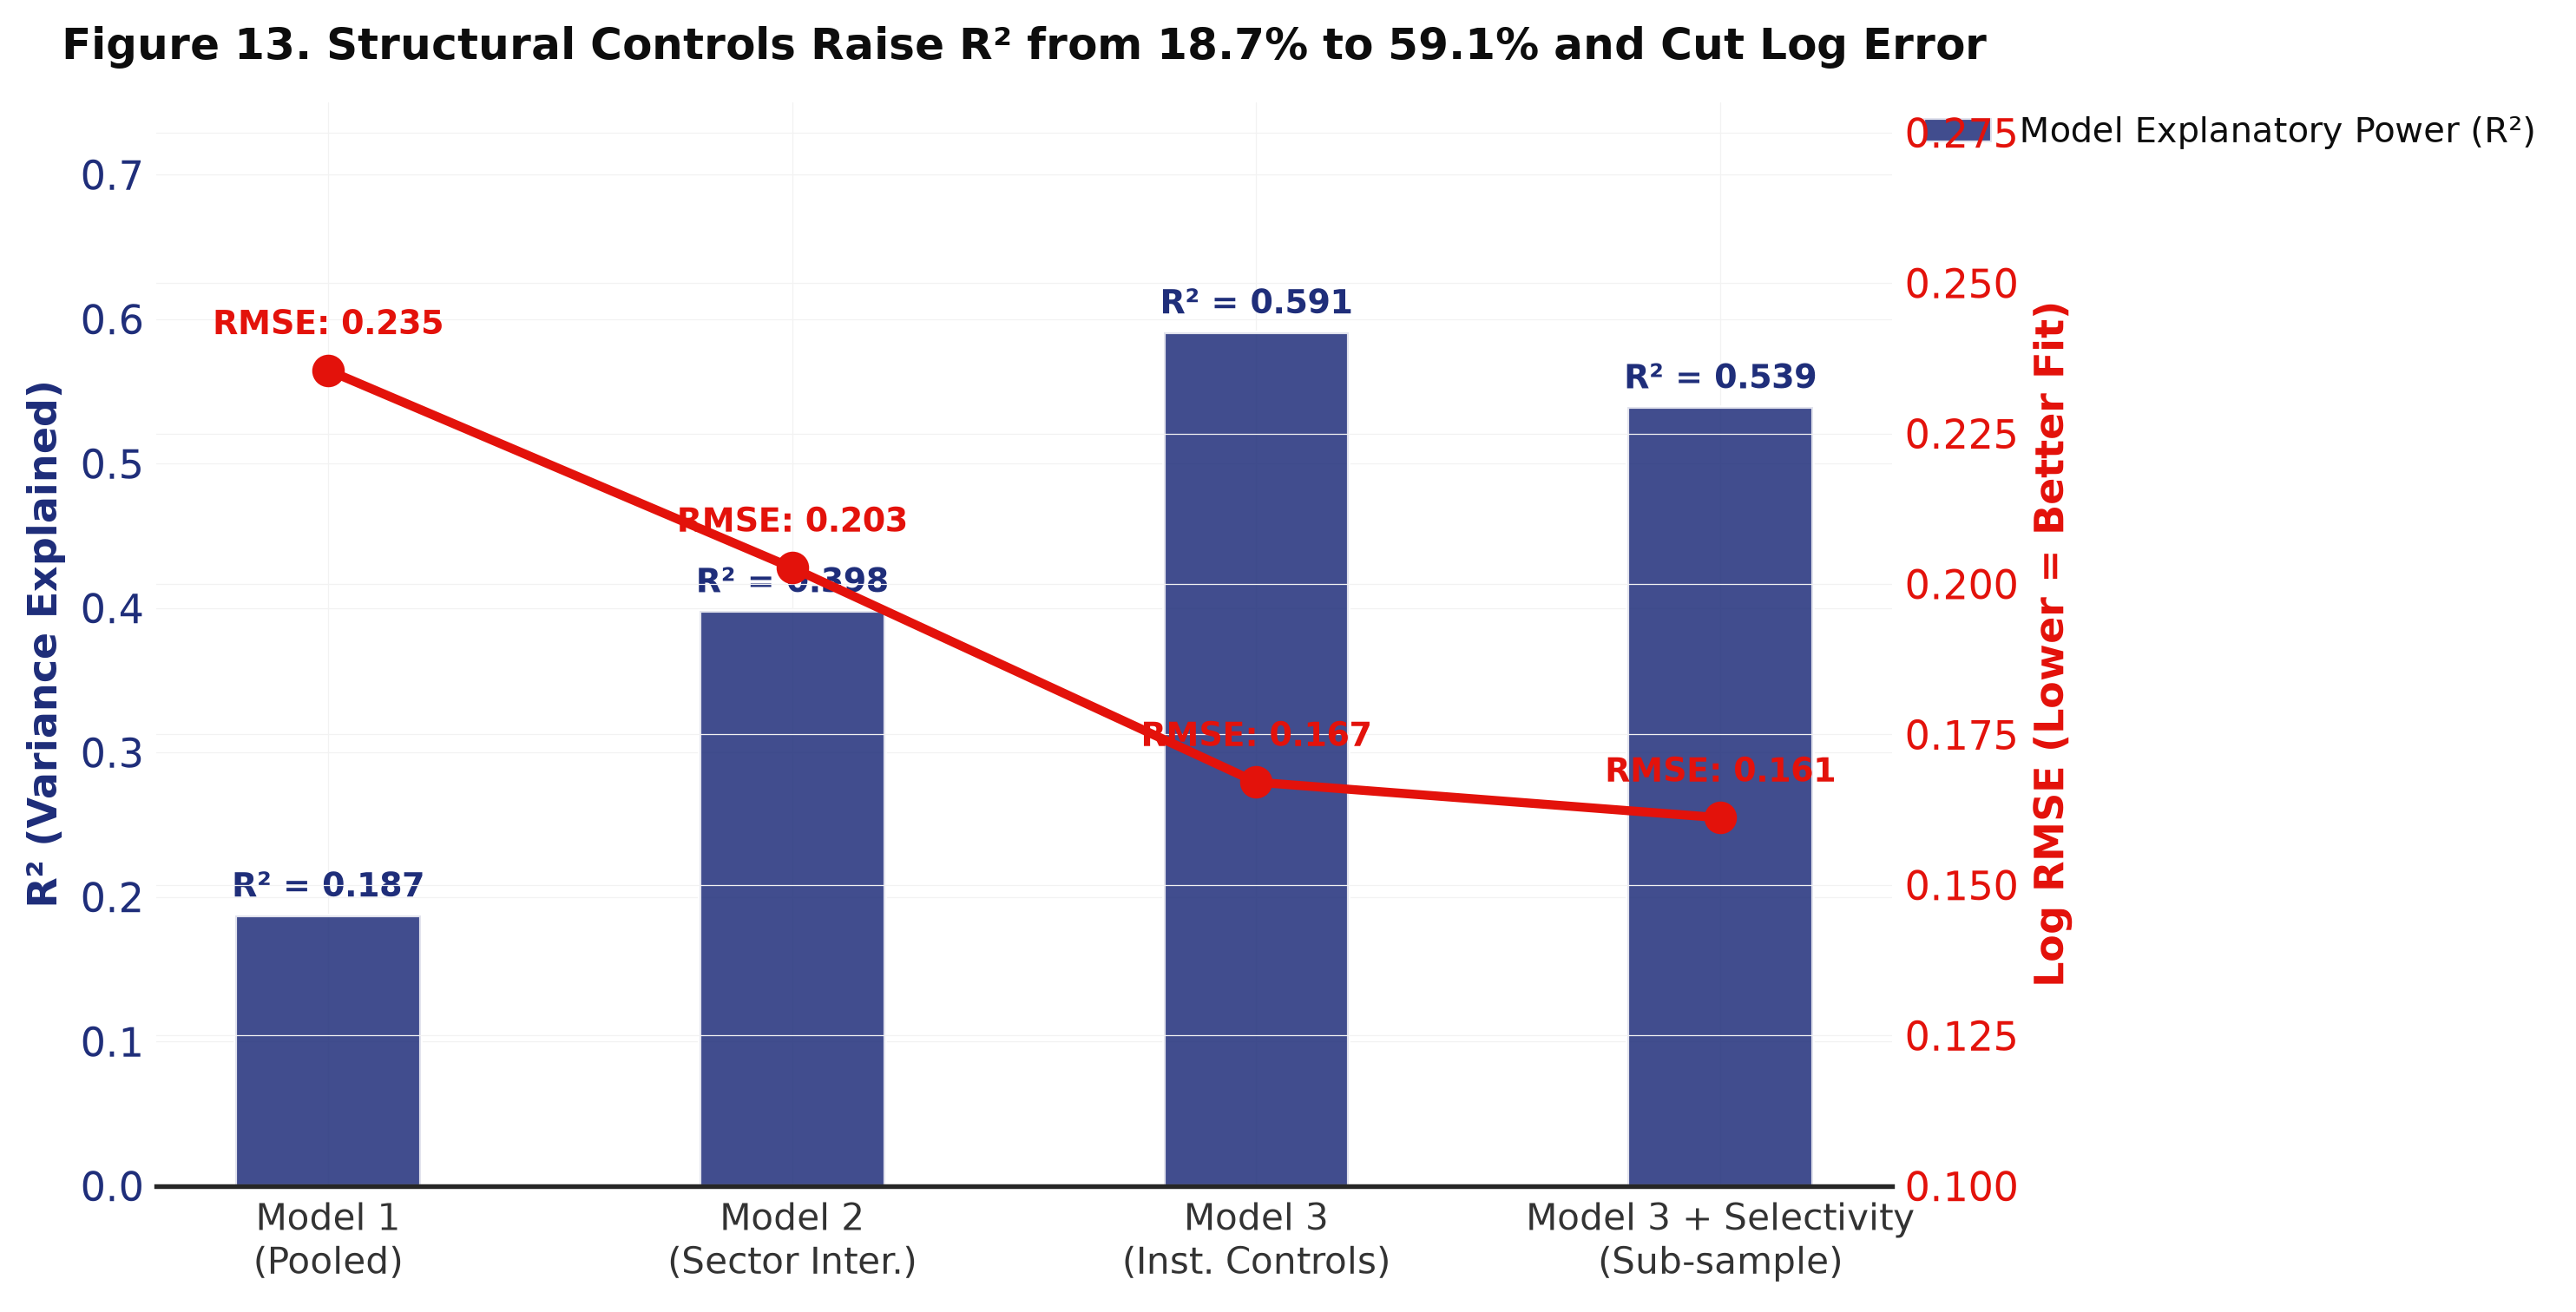

In [15]:
slopes_m3 = sector_slope_table(model3).loc[sector_order]
slopes_m3_restricted = sector_slope_table(model3_selectivity_subset).loc[sector_order]
slopes_m3_selectivity = sector_slope_table(model3_with_selectivity).loc[sector_order]

fig11, ax11 = plt.subplots(figsize=(12.0, 5.5), dpi=300)
y_positions = np.array([2.0, 1.0, 0.0])

spec_configs = [
    ("Full-sample Model 3", slopes_m3, "#1F2E7A", 0.2),
    ("Restricted Model 3", slopes_m3_restricted, "#475ED1", 0.0),
    ("Restricted Model 3 + Selectivity", slopes_m3_selectivity, "#E3120B", -0.2),
]

for label, slopes_df, color, offset in spec_configs:
    pos = y_positions + offset
    betas = slopes_df["Tuition elasticity"].to_numpy()
    err_low = betas - slopes_df["CI lower"].to_numpy()
    err_high = slopes_df["CI upper"].to_numpy() - betas
    ax11.errorbar(
        betas, pos, xerr=np.vstack([err_low, err_high]),
        fmt="o", color=color, capsize=5, label=label, markersize=7
    )

ax11.axvline(0, color="#595959", linestyle="--", linewidth=1.2)
ax11.set_yticks(y_positions)
ax11.set_yticklabels(sector_order, fontsize=11, fontweight="bold")
ax11.set_xlabel("Tuition Elasticity of Median Earnings (beta with 95% HC3 CI)", fontsize=11)
ax11.set_title("Figure 11. Selectivity Controls Narrow Sector Tuition Elasticity Differences", pad=12, fontsize=12)
ax11.legend(fontsize=9.5, loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0.0)
ax11.grid(axis="x", linestyle="-", color="#F2F2F2", linewidth=0.5)
fig11.tight_layout(rect=(0, 0, 0.80, 1))

fig12, ax12 = plt.subplots(figsize=(12.0, 6.5), dpi=300)

full_series = model_data["CONTROL_LABEL"].value_counts().reindex(sector_order)
restricted_series = selectivity_data["CONTROL_LABEL"].value_counts().reindex(sector_order)

full_counts = full_series.to_numpy()
restricted_counts = restricted_series.to_numpy()

x = np.arange(len(sector_order))
width = 0.35

rects1 = ax12.bar(x - width/2, full_counts, width, label=f"Full Sample (N = {len(model_data):,})", color="#1F2E7A")
rects2 = ax12.bar(x + width/2, restricted_counts, width, label=f"Reporting Admission Rates (N = {len(selectivity_data):,})", color="#E3120B")

ax12.set_ylabel("Number of Institutions", fontsize=11)
ax12.set_title("Figure 12. Listwise Deletion Imposes Severe Bias on For-Profit Reporting", pad=14, fontsize=12)
ax12.set_xticks(x)
ax12.set_xticklabels(sector_order, fontsize=11, fontweight="bold")
ax12.set_ylim(0, 1850)
ax12.legend(fontsize=9.5, loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0.0)
ax12.grid(axis="y", linestyle="-", color="#F2F2F2", linewidth=0.5)

for rect in rects1:
    height = rect.get_height()
    ax12.annotate(f"{int(height):,}", xy=(rect.get_x() + rect.get_width()/2, height),
                 xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=9.5, fontweight="bold")

for rect in rects2:
    height = rect.get_height()
    ax12.annotate(f"{int(height):,}", xy=(rect.get_x() + rect.get_width()/2, height),
                 xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=9.5, fontweight="bold", color="#B30000")

fig12.tight_layout(rect=(0, 0, 0.82, 1))

fig13, ax13_left = plt.subplots(figsize=(12.0, 5.2), dpi=300)

models_list = [model1, model2, model3, model3_with_selectivity]
model_labels = ["Model 1\n(Pooled)", "Model 2\n(Sector Inter.)", "Model 3\n(Inst. Controls)", "Model 3 + Selectivity\n(Sub-sample)"]

r2_values = [m.rsquared for m in models_list]
rmse_values = [np.sqrt(np.mean(np.square(m.resid))) for m in models_list]

x_m = np.arange(len(model_labels))

color_r2 = "#1F2E7A"
color_rmse = "#E3120B"

bars = ax13_left.bar(x_m, r2_values, width=0.4, color=color_r2, alpha=0.85, label="Model Explanatory Power (R²)")
ax13_left.set_ylabel("R² (Variance Explained)", color=color_r2, fontsize=11, fontweight="bold")
ax13_left.tick_params(axis="y", labelcolor=color_r2)
ax13_left.set_ylim(0, 0.75)

for bar in bars:
    h = bar.get_height()
    ax13_left.annotate(f"R² = {h:.3f}", xy=(bar.get_x() + bar.get_width()/2, h),
                      xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=9, fontweight="bold", color=color_r2)

ax13_right = ax13_left.twinx()
line = ax13_right.plot(x_m, rmse_values, color=color_rmse, marker="o", linewidth=2.5, markersize=8, label="Log RMSE (Error)")
ax13_right.set_ylabel("Log RMSE (Lower = Better Fit)", color=color_rmse, fontsize=11, fontweight="bold")
ax13_right.tick_params(axis="y", labelcolor=color_rmse)
ax13_right.set_ylim(0.10, 0.28)

for i, txt in enumerate(rmse_values):
    ax13_right.annotate(f"RMSE: {txt:.3f}", (x_m[i], rmse_values[i]), xytext=(0, 10), textcoords="offset points", ha="center", fontsize=9, color=color_rmse, fontweight="bold")

ax13_left.set_xticks(x_m)
ax13_left.set_xticklabels(model_labels, fontsize=10)
ax13_left.set_title(f"Figure 13. Structural Controls Raise R² from {r2_values[0]:.1%} to {r2_values[2]:.1%} and Cut Log Error", pad=12, fontsize=12)
ax13_left.legend(fontsize=9.5, loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0.0)
fig13.tight_layout(rect=(0, 0, 0.84, 1))
plt.show()


### 7. Methodological References

- **Dale, S. B., & Krueger, A. B. (2011).** Estimating the payoff to attending a more selective college: An application of the selection on observables estimator. *Journal of Human Resources*, 46(2), 407–440. https://doi.org/10.3368/jhr.46.2.407
- **Faber, A. (2017).** *The impact of college attributes on the earnings of community college graduates* [Doctoral dissertation, University of Toledo]. OhioLINK Electronic Theses and Dissertations Center. http://rave.ohiolink.edu/etdc/view?acc_num=toledo151335572292832
- **Faber, A., & Slantcheva-Durst, S. (2021).** The impact of community college attributes on the earnings of their students. *Community College Journal of Research and Practice*, 45(9), 687–700. https://doi.org/10.1080/10668926.2020.1798302
- **Hotelling, H., & Pabst, M. R. (1936).** Rank correlation and tests of significance involving no assumption of normality. *The Annals of Mathematical Statistics*, 7(1), 22–43. https://doi.org/10.1214/aoms/1177732543
- **MacKinnon, J. G., & White, H. (1985).** Some heteroskedasticity-consistent covariance matrix estimators with improved finite sample properties. *Journal of Econometrics*, 29(3), 305–325. https://doi.org/10.1016/0304-4076(85)90158-7
- **Muse, W. B., & Muse, I. (2024).** College selectivity, choice of major, and post-college earnings. *Journal of Economic Analysis*, 3(2), 33–51. https://doi.org/10.58567/jea03020003
- **Pepinsky, T. B. (2018).** A note on listwise deletion and missing data in administrative datasets. *Political Analysis*, 26(2), 235–244. https://doi.org/10.1017/pan.2017.42